# Yanxing Liu TS Advisor — Trouble Report Routing Classification

## Problem Statement

Ericsson's 4G/5G Radio system generates thousands of **Trouble Reports (TRs)**
per year. Each TR describes a fault observed in the field or in testing. When
submitted, a TR must be routed to the correct **design team (MHO)** for
investigation and resolution.

Currently this routing is done manually or via a rule-based system with limited
coverage (~30% auto-routed). The goal of this notebook is to build a machine
learning classifier that predicts the correct MHO team from the TR content at
submission time — before the TR has been solved.

## Business Value

- **Faster routing**: reduce time a TR spends waiting in triage queues
- **Consistent routing**: remove human variability in routing decisions
- **Scalability**: handle increasing TR volume without proportional triage effort
- **Confidence gating**: the system can say "I don't know" and send ambiguous
  TRs to human triage, avoiding costly mis-routing

## Data Source

- `4G5G_trr_trs_20000.csv` — ~22,000 Trouble Reports from the 4G/5G system
- Target label: `Faulty product.Design Responsible MHO` (the team that solved the TR)

## Solution Architecture

```
Training:  CSV → Clean → Split → Per-section TF-IDF + Engineered Features
                → Train LinearSVC/LogReg → Calibrate → Evaluate

Inference: New TR → Same feature extraction → Predict team + confidence
                → confidence > threshold → auto-route
                → confidence ≤ threshold → human triage
```

## Pipeline Steps

| Step | What | Key Decision |
|---|---|---|
| 0 | Configuration | `RUN_MODE` controls speed/accuracy tradeoff |
| 1 | Load & Inspect | `engine='c'` for correct CSV parsing |
| 2 | Data Cleaning | Dedup, rare-class handling (`MIN_SAMPLES=100`, `DROP_OTHER`) |
| 3 | EDA | Understand distributions before feature engineering |
| 4 | Feature Engineering | Per-section TF-IDF, categorical, engineered features |
| 5 | Baseline Models | 4-candidate shortlist with explicit roles |
| 5b | Hierarchical | Two-stage classifier (Superior MHO → team) |
| 6 | Bias/Variance | Learning curves diagnose under/overfitting |
| 7 | Tuning | GridSearchCV on training data only |
| 8 | Forward Selection | Which feature groups actually contribute? |
| 9 | Transformer | DistilBERT/SBERT as accuracy ceiling |
| 10 | Final Evaluation | Test set once; macro F1, precision-coverage, McNemar |
| 10b | Confidence Routing | Platt-scaled probabilities + threshold |
| 10c | Duplicate Detection | SBERT cosine similarity for near-duplicates |
| 11 | Permutation Importance | Causal feature-group attribution |

## Success Criteria

| Metric | Target |
|---|---|
| Macro F1 (test) | ≥ 0.70 |
| Precision at 70% coverage | ≥ 0.85 |
| McNemar p-value (best vs runner-up) | < 0.05 |
| End-to-end runtime (`fast` mode) | < 45 min |


---
## Step 1: Load & Inspect Data

**What:** Load the 380 MB CSV into a pandas DataFrame and examine its structure.

**Why:** The CSV has multi-line quoted text fields (Observation and Answer can be
thousands of characters with embedded commas and newlines). Standard pandas
defaults with `engine='python'` mis-parse these, producing ~123k rows instead of
the correct 22,293. Using `engine='c'` with explicit quoting parameters handles
this correctly.

**How:** `pd.read_csv(CSV_PATH, engine='c', encoding='latin-1', quotechar='"',
doublequote=True, on_bad_lines='skip', low_memory=False)`

**Key columns:**
- `General.Heading` — short subject line (always available at routing time)
- `Observation.Observation` — structured fault description (available at routing)
- `Answer.Answer` — root cause analysis (only available AFTER solving; used for
  training enrichment only)
- `Faulty product.Design Responsible MHO` — the target label (team that solved it)
- `General.Superior MHO` — high-level system (LTE-MS-RBS or ERS-RADIO)
- `Observation.Fault type` — observed symptom category


In [2]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# Full dataset path — place the CSV in the same directory as this notebook
CSV_PATH = r'./Project_4_TS_Advisor/4G5G_trr_trs_20000.csv'

# IMPORTANT: engine='c' is required to correctly parse this CSV.
# The file has multi-line quoted fields (Observation, Answer) with embedded
# commas and newlines. engine='python' mis-parses these and produces 123k rows
# instead of the correct 22,293. engine='c' handles the quoting correctly.
# encoding='latin-1' handles non-UTF8 characters in technical text.
_csv_kwargs = dict(
    sep=',',
    quotechar='"',
    doublequote=True,
    engine='c',
    encoding='latin-1',
    low_memory=False,
)
try:
    # pandas >= 1.3
    df = pd.read_csv(CSV_PATH, on_bad_lines='skip', **_csv_kwargs)
except TypeError:
    # pandas < 1.3
    df = pd.read_csv(CSV_PATH, error_bad_lines=False, **_csv_kwargs)

print(f'Dataset shape: {df.shape}')  # expected: (22293, 38)
print(f'\nColumn names:')
for c in df.columns:
    print(f'  {c}')


Dataset shape: (22293, 38)

Column names:
  General.Eriref
  Faulty product.Design Responsible MHO
  General.Submitter priority
  General.Heading
  Observation.Observation
  Answer.Answer
  General.Is duplicate TR
  General.Primary TR
  General.Duplicate TRs
  TR History Register.Register date
  General.Superior MHO
  General.Status code
  Observation.Fault type
  Analysis.Fault type
  Improvement.Type explanation
  Network level.Product no
  Network level.Product no & R-State
  Node level.Product no
  Node level.Product no & R-State
  Node component level.Product no
  Node component level.Product no & R-State
  Faulty product.Product no
  Faulty product.Product no & R-State
  Faulty product.Original Product no
  Faulty product.Original Product no & R-State
  Faulty product.Feature Product no
  Faulty product.Feature Product no & R-State
  Registered
  to_radionode
  Before_assign
  Before_last_assign
  Accept_or_Cancelled
  routing_time
  routing_waiting_time
  total_routing_time
  to

In [3]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  RUN MODE CONFIGURATION — Controls speed/accuracy tradeoff          ║
# ║  Change this ONE variable to control the entire pipeline.           ║
# ╚══════════════════════════════════════════════════════════════════════╝

RUN_MODE = 'fast'  # Options: 'fast', 'balanced', 'full'

# ┌─────────────────────────────────────────────────────────────────────┐
# │ Mode     │ Total Time │ Accuracy  │ Use Case                        │
# ├──────────┼────────────┼───────────┼─────────────────────────────────┤
# │ 'fast'   │ ~30-45 min │ ~70-77%   │ Development, debugging, demos   │
# │ 'balanced'│ ~1-2 hours│ ~73-79%   │ Normal runs, presentations      │
# │ 'full'   │ ~15-20 hrs│ ~75-82%   │ Final submission, best accuracy  │
# └─────────────────────────────────────────────────────────────────────┘

# Derived settings from RUN_MODE
CONFIG = {
    'fast': {
        'max_features'  : 3000,
        'ngram_range'   : (1, 1),     # unigrams only — smaller vocab
        'cv_folds'      : 2,
        'learning_sizes': 4,
        'grid_C'        : [0.1, 1.0],
        'grid_cw'       : [None, 'balanced'],
        'grid_loss'     : ['squared_hinge'],
        'slow_models'   : False,      # skip RF, MLP, XGBoost
        'use_sbert'     : False,      # skip SBERT encoding
    },
    'balanced': {
        'max_features'  : 5000,
        'ngram_range'   : (1, 2),     # unigrams + bigrams
        'cv_folds'      : 2,
        'learning_sizes': 5,
        'grid_C'        : [0.1, 1.0, 5.0],
        'grid_cw'       : [None, 'balanced'],
        'grid_loss'     : ['hinge', 'squared_hinge'],
        'slow_models'   : False,
        'use_sbert'     : True,
    },
    'full': {
        'max_features'  : 20000,
        'ngram_range'   : (1, 2),
        'cv_folds'      : 3,
        'learning_sizes': 8,
        'grid_C'        : [0.01, 0.1, 0.5, 1.0, 5.0],
        'grid_cw'       : [None, 'balanced'],
        'grid_loss'     : ['hinge', 'squared_hinge'],
        'slow_models'   : True,       # include RF, MLP, XGBoost
        'use_sbert'     : True,
    },
}[RUN_MODE]

print(f'RUN_MODE          : {RUN_MODE}')
print(f'TF-IDF features   : {CONFIG["max_features"]}')
print(f'Ngram range       : {CONFIG["ngram_range"]}')
print(f'CV folds          : {CONFIG["cv_folds"]}')
print(f'GridSearch C vals  : {CONFIG["grid_C"]}')
print(f'Slow models       : {CONFIG["slow_models"]}')
print(f'Use SBERT         : {CONFIG["use_sbert"]}')


RUN_MODE          : fast
TF-IDF features   : 3000
Ngram range       : (1, 1)
CV folds          : 2
GridSearch C vals  : [0.1, 1.0]
Slow models       : False
Use SBERT         : False


---
## Utilities

A single cell of helpers used throughout the notebook. Defining them once
here keeps the downstream cells focused on analysis rather than plumbing.

- **`SafeLabelEncoder`** — wraps `LabelEncoder` and maps unseen categories
  at transform-time to a configured `'unknown'` bucket instead of raising.
  Use `strategy='warn'` for input features (low-risk columns) and
  `strategy='raise'` for the prediction target (silent remap would hide
  upstream problems).
- **`evaluate(model, X, y, name)`** — one place where metrics are computed.
  Returns a dict with accuracy, macro F1, weighted F1 and sample count so
  that every downstream table has the same columns.
- **`assert_split_consistency(...)`** — data-contract check. Lists every
  value present in val/test but not in train for a set of columns. Prints
  a warning; caller decides what to do.
- **Text helpers** — `clean_text`, `extract_effect_section`,
  `extract_cause_of_fault`, `extract_observation_sections`, and
  `build_text_column` are all here so the feature-engineering cells can
  simply call them.


In [4]:
import re
import warnings
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

# ------------------------------------------------------------------
# SafeLabelEncoder: label encoder that doesn't explode on unseen values
# ------------------------------------------------------------------
class SafeLabelEncoder:
    """LabelEncoder that handles unseen categories at transform time.

    strategy='warn'  : unseen values -> `unknown_token`, a warning is printed.
                        The `unknown_token` is automatically added to the
                        encoder's class list during fit, so the downstream
                        classifier will see it as a real class.
    strategy='raise' : unseen values raise ValueError. Use for target labels
                        where a silent remap would hide upstream problems.
    """
    def __init__(self, strategy='warn', unknown_token='__unknown__'):
        assert strategy in ('warn', 'raise')
        self.strategy      = strategy
        self.unknown_token = unknown_token
        self._le           = LabelEncoder()

    def fit(self, y):
        y = pd.Series(y).fillna(self.unknown_token).astype(str)
        if self.strategy == 'warn' and self.unknown_token not in set(y):
            # Add the unknown token so unseen values at transform-time have
            # a valid class to map to.
            y = pd.concat([y, pd.Series([self.unknown_token])], ignore_index=True)
        self._le.fit(y)
        self.classes_ = self._le.classes_
        return self

    def transform(self, y):
        y = pd.Series(y).fillna(self.unknown_token).astype(str)
        known = set(self._le.classes_)
        unseen = sorted(set(y) - known)
        if unseen:
            if self.strategy == 'raise':
                raise ValueError(f'Unseen labels during transform: {unseen}')
            warnings.warn(
                f'{len(unseen)} unseen value(s) remapped to '
                f'{self.unknown_token!r}: {unseen[:5]}' +
                ('...' if len(unseen) > 5 else ''))
            y = y.where(y.isin(known), self.unknown_token)
        return self._le.transform(y)

    def fit_transform(self, y):
        return self.fit(y).transform(y)

    def inverse_transform(self, y):
        return self._le.inverse_transform(y)


# ------------------------------------------------------------------
# Unified evaluate() — every downstream metric call goes through this
# ------------------------------------------------------------------
def evaluate(model, X, y_true, name, y_train=None, X_train=None):
    """Compute a dict of metrics for one (model, X, y) triple.

    Returns keys: name, accuracy, macro_f1, weighted_f1, n_samples.
    If X_train, y_train are given, adds train_accuracy and gap for
    overfitting diagnosis.
    """
    y_pred   = model.predict(X)
    out = {
        'name'        : name,
        'accuracy'    : accuracy_score(y_true, y_pred),
        'macro_f1'    : f1_score(y_true, y_pred, average='macro', zero_division=0),
        'weighted_f1' : f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'n_samples'   : len(y_true),
    }
    if X_train is not None and y_train is not None:
        tr_pred = model.predict(X_train)
        out['train_accuracy'] = accuracy_score(y_train, tr_pred)
        out['gap']            = out['train_accuracy'] - out['accuracy']
    return out


# ------------------------------------------------------------------
# Data-contract check — run after the split
# ------------------------------------------------------------------
def assert_split_consistency(train, val, test, cols, verbose=True):
    """Report values present in val/test but not in train for each column.

    Does NOT raise — it warns. The caller decides whether this is fatal
    (call `assert` on the returned count) or informational.
    """
    issues = {}
    for col in cols:
        tr_vals = set(train[col].dropna().unique())
        va_only = sorted(set(val[col].dropna().unique())  - tr_vals)
        te_only = sorted(set(test[col].dropna().unique()) - tr_vals)
        if va_only or te_only:
            issues[col] = {'val_only': va_only, 'test_only': te_only}
            if verbose:
                print(f'WARNING {col!r}: val_only={va_only}, test_only={te_only}')
    if not issues and verbose:
        print(f'OK: all values in {len(cols)} columns are present in training data')
    return issues


# ------------------------------------------------------------------
# Text preprocessing helpers
# ------------------------------------------------------------------
def clean_text(text):
    """Lowercase, keep only letters and whitespace, collapse runs of whitespace."""
    if pd.isna(text): return ''
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text))
    return ' '.join(text.lower().split())


def clean_text_keep_alphanum(text):
    """Like clean_text but keeps digits and dots — useful for Configuration Data
    sections where tokens like 'BB6630', '21.Q3', 'R87H14' carry routing signal."""
    if pd.isna(text): return ''
    text = re.sub(r'[^a-zA-Z0-9.\s]', ' ', str(text))
    return ' '.join(text.lower().split())


def extract_effect_section(text):
    """Extract '1 EFFECT' section. Fall back to full text if structure missing."""
    if not text or pd.isna(text): return ''
    pat = r'1\s+E\s*F\s*F\s*E\s*C\s*T\s*.*?\n={5,}(.*?)(?=2\s+T\s*R\s*O\s*U\s*B\s*L\s*E)'
    m = re.search(pat, text, re.DOTALL | re.IGNORECASE)
    return m.group(1).strip() if m else str(text)


def extract_observation_sections(text):
    """Split Observation.Observation into its five major sections and return a
    dict. Missing sections are empty strings, not None, so downstream code can
    concatenate without conditionals.

    Sections:
      effect      : '1 EFFECT' (symptom, most compressed)
      trouble     : '2 TROUBLE DESCRIPTION' (details + logs; usually noisy)
      config      : '2.2 Configuration Data' (board/SW IDs; alphanumeric preserved)
      measures    : '3 MEASURES' (workaround; sometimes names team)
      csr         : '4 CSR Consultation' (support reference)
    """
    if not text or pd.isna(text):
        return {k: '' for k in ['effect', 'trouble', 'config', 'measures', 'csr']}
    t = str(text)
    def grab(pattern):
        m = re.search(pattern, t, re.DOTALL | re.IGNORECASE)
        return m.group(1).strip() if m else ''
    return {
        'effect'  : grab(r'1\s+E\s*F\s*F\s*E\s*C\s*T.*?\n={3,}(.*?)(?=\n\s*2\s+T\s*R\s*O\s*U\s*B\s*L\s*E|$)'),
        'trouble' : grab(r'2\s+T\s*R\s*O\s*U\s*B\s*L\s*E.*?\n={3,}(.*?)(?=\n\s*3\s+M\s*E\s*A\s*S\s*U\s*R\s*E|$)'),
        'config'  : grab(r'2\.2\s+Configuration\s+Data.*?\n-{3,}(.*?)(?=\n\s*2\.3|\n\s*3\s+M\s*E\s*A\s*S|$)'),
        'measures': grab(r'3\s+M\s*E\s*A\s*S\s*U\s*R\s*E.*?\n={3,}(.*?)(?=\n\s*4|$)'),
        'csr'     : grab(r'4\s+CSR.*?\n={3,}(.*?)(?=$)'),
    }


def extract_cause_of_fault(text):
    """Extract 'CAUSE OF FAULT' section from Answer.Answer."""
    if not text or pd.isna(text): return ''
    m = re.search(r'CAUSE OF FAULT\s*\n-{10,}(.*?)(?=\n-{10,})', text, re.DOTALL | re.IGNORECASE)
    return m.group(1).strip() if m else str(text)


def build_text_column(dataframe, use_answer=False):
    """Legacy single-string text builder. Kept for backward compatibility
    with cells that don't need per-section TF-IDF."""
    heading = dataframe['General.Heading'].fillna('')
    effect  = dataframe['Observation.Observation'].apply(extract_effect_section)
    if use_answer:
        cause    = dataframe['Answer.Answer'].apply(extract_cause_of_fault)
        combined = heading + ' [SEP] ' + effect + ' [SEP] ' + cause
    else:
        combined = heading + ' [SEP] ' + effect
    return combined.apply(clean_text).tolist()


print('Utilities loaded: SafeLabelEncoder, evaluate, assert_split_consistency, '
      'clean_text, extract_* helpers, build_text_column')


Utilities loaded: SafeLabelEncoder, evaluate, assert_split_consistency, clean_text, extract_* helpers, build_text_column


In [5]:
# Inspect data types and missing value rates for every column
# This tells us which features are usable and which need imputation or dropping
info_df = pd.DataFrame({
    'dtype'     : df.dtypes,
    'non_null'  : df.count(),
    'null_count': df.isnull().sum(),
    'null_pct'  : (df.isnull().sum() / len(df) * 100).round(1)
})
print(info_df.to_string())

                                                dtype  non_null  null_count  null_pct
General.Eriref                                 object     22293           0       0.0
Faulty product.Design Responsible MHO          object     22293           0       0.0
General.Submitter priority                     object     22293           0       0.0
General.Heading                                object     22293           0       0.0
Observation.Observation                        object     22283          10       0.0
Answer.Answer                                  object     22257          36       0.2
General.Is duplicate TR                          bool     22293           0       0.0
General.Primary TR                             object      3306       18987      85.2
General.Duplicate TRs                          object      5019       17274      77.5
TR History Register.Register date              object     22293           0       0.0
General.Superior MHO                           object 

In [6]:
# Preview key columns to understand data format
key_cols = [
    'General.Eriref',
    'Faulty product.Design Responsible MHO',
    'General.Submitter priority',
    'General.Heading',
    'General.Is duplicate TR',
    'General.Primary TR',
    'General.Duplicate TRs',
    'General.Superior MHO',
    'Observation.Fault type',
    'Analysis.Fault type'
]
df[key_cols].head(10)

,General.Eriref,Faulty product.Design Responsible MHO,General.Submitter priority,General.Heading,General.Is duplicate TR,General.Primary TR,General.Duplicate TRs,General.Superior MHO,Observation.Fault type,Analysis.Fault type
0,HZ38812,RCS-DEV,B,Emergency Unlock does not unlock the capacitie...,False,NaN,NaN,LTE-MS-RBS,CELLDISABLED,NaN
1,HZ38535,CAT-IPT,B,MB G2 Mixed Mode C2 - Alarm Resource Activatio...,False,NaN,NaN,LTE-MS-RBS,ALARM,NaN
2,HZ38006,RADIOSW,A,MR8384 DOT4455 FFI:IRU1649 SW error alarm and ...,False,NaN,HZ39141,LTE-MS-RBS,ALARM,NaN
3,HZ37845,TCSW-SECTCA,B,RGW SP035: One NR SC & Cell (ESS paired) in un...,False,NaN,NaN,LTE-MS-RBS,OTHER,NaN
4,HZ37761,LTE-UPCDL,A,"21.Q2 IP3 EC1 site stop taking traffic, paging...",False,NaN,NaN,LTE-MS-RBS,COUNTERS&EVENTS,NaN
5,HZ37627,TCSW-SECTCA,B,<NBV G2 NRHB>SectorCarrier isn't accessible wi...,False,NaN,HZ37780,LTE-MS-RBS,CELLDISABLED,NaN
6,HZ37627,TCSW-SECTCA,B,<NBV G2 NRHB>SectorCarrier isn't accessible wi...,False,NaN,HZ38391,LTE-MS-RBS,CELLDISABLED,NaN
7,HZ37627,TCSW-SECTCA,B,<NBV G2 NRHB>SectorCarrier isn't accessible wi...,False,NaN,HZ39457,LTE-MS-RBS,CELLDISABLED,NaN
8,HZ37627,TCSW-SECTCA,B,<NBV G2 NRHB>SectorCarrier isn't accessible wi...,False,NaN,HZ41042,LTE-MS-RBS,CELLDISABLED,NaN
9,HZ37627,TCSW-SECTCA,B,<NBV G2 NRHB>SectorCarrier isn't accessible wi...,False,NaN,HZ37945,LTE-MS-RBS,CELLDISABLED,NaN


In [7]:
# Check the target label column specifically
# This is the MHO field we want to predict
mho_col = 'Faulty product.Design Responsible MHO'
print(f"Total rows                  : {len(df)}")
print(f"Unique MHO labels           : {df[mho_col].nunique()}")
print(f"Null MHO rows               : {df[mho_col].isna().sum()}")
print(f"\nTop 20 most frequent MHO labels:")
print(df[mho_col].value_counts().head(20).to_string())

Total rows                  : 22293
Unique MHO labels           : 222
Null MHO rows               : 0

Top 20 most frequent MHO labels:
TC-SW          2089
LTE-UEH        1767
RADIOSW        1703
LTE-BBSW       1528
RCS-DEV        1100
LMR-RNH         839
LTE-UPCUL       760
LTE-UPCDL       696
BBI-BBISW       592
CAT-CRA         592
LTE-OAM         564
CAT-NC          563
NR-EMCASW       519
CAT-UC          364
LTE-ULL1        345
LTE-RBS-CPI     341
TCSW-PP         333
NR-ULPHY        331
LMR-LRH         288
NR-EMCASW-A     269


---
## Step 2: Data Cleaning

**What:** Prepare the raw data for supervised learning by removing noise and
handling class imbalance.

**Why:** Real-world datasets are never clean. Duplicates inflate metrics, null
labels break supervised learning, and rare classes produce unreliable per-class
metrics. Cleaning is the foundation everything else rests on.

**How — three tasks:**

**2.1 Deduplicate by `General.Eriref`**

Per the README, if a TR has N duplicate TRs it appears N times in the CSV (all
fields identical except `General.Duplicate TRs`). Without dedup, the same TR
would appear in both train and test — data leakage. We keep the first occurrence
of each unique Eriref.

**2.2 Drop null targets**

Rows without a `Design Responsible MHO` label cannot be used for supervised
learning. They're dropped.

**2.3 Handle rare classes (`MIN_SAMPLES=100`, `DROP_OTHER`)**

With 222 MHO labels and ~22k rows, many labels have fewer than 10 samples. A
model cannot learn a reliable pattern from 5 examples. The threshold is set to
100 so each kept class has at least ~20 samples per split after 60/20/20
stratification — enough for per-class F1 to be statistically meaningful.

Two modes:
- `DROP_OTHER = False` (default): merge rare labels into `'other'` and train on it
- `DROP_OTHER = True`: drop those rows entirely; rare-team TRs are deferred to
  human triage via the confidence gate in Step 10b


In [8]:
# --- 2.1 Deduplicate by Eriref ---
# README: a TR with N duplicate TRs appears N times, identical except General.Duplicate TRs
# We keep the first occurrence of each unique TR
print(f"Rows before dedup : {len(df)}")
print(f"Unique Erirefs    : {df['General.Eriref'].nunique()}")

df = df.drop_duplicates(subset='General.Eriref', keep='first').copy()
print(f"Rows after dedup  : {len(df)}")

Rows before dedup : 22293
Unique Erirefs    : 19556
Rows after dedup  : 19556


In [9]:
# --- 2.2 Drop rows with null MHO target ---
mho_col = 'Faulty product.Design Responsible MHO'
null_mho = df[mho_col].isna().sum()
print(f"Rows with null MHO (dropped): {null_mho}")

df = df[df[mho_col].notna()].copy()
print(f"Rows after null drop        : {len(df)}")
print(f"Unique MHO labels remaining : {df[mho_col].nunique()}")

Rows with null MHO (dropped): 0
Rows after null drop        : 19556
Unique MHO labels remaining : 222


Class size distribution:
  [    1 -    10) samples : 115 classes
  [   10 -    50) samples : 52 classes
  [   50 -   100) samples : 15 classes
  [  100 -   200) samples : 17 classes
  [  200 -   500) samples : 13 classes
  [  500 -  1000) samples : 6 classes
  [ 1000 -  1835) samples : 4 classes


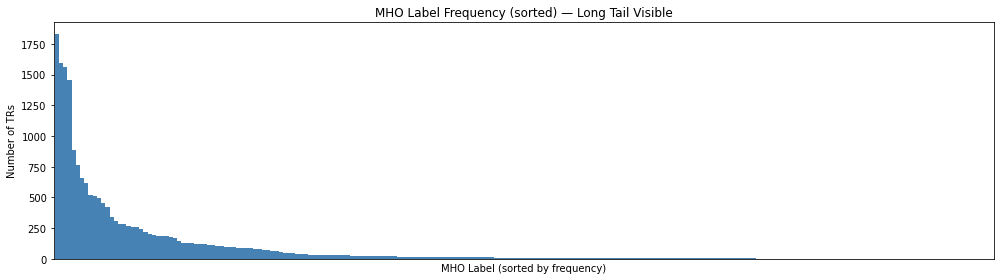

In [10]:
# --- 2.3 Analyse class distribution before merging ---
import matplotlib.pyplot as plt

label_counts = df[mho_col].value_counts()

# Show distribution of class sizes
print("Class size distribution:")
bins = [1, 10, 50, 100, 200, 500, 1000, label_counts.max()+1]
for i in range(len(bins)-1):
    count = ((label_counts >= bins[i]) & (label_counts < bins[i+1])).sum()
    print(f"  [{bins[i]:>5} - {bins[i+1]:>5}) samples : {count} classes")

# Visualise the long tail
fig, ax = plt.subplots(figsize=(14, 4))
label_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none', width=1.0)
ax.set_title('MHO Label Frequency (sorted) — Long Tail Visible')
ax.set_xlabel('MHO Label (sorted by frequency)')
ax.set_ylabel('Number of TRs')
ax.set_xticks([])
plt.tight_layout()
plt.show()

In [11]:
# --- 2.3 Handle rare classes ---
# Classes with fewer samples than MIN_SAMPLES are too sparse to learn
# reliably. The threshold is chosen so each split still contains enough
# rows per class for reliable metrics: 100 samples => ~20 in val and test
# after a 60/20/20 stratified split.
#
# Two ways to handle them, controlled by DROP_OTHER:
#   False (default): merge all rare classes into a single 'other' label
#                    and train on it. Keeps the dataset size but the
#                    'other' class is heterogeneous and hard to learn.
#   True           : drop rare-class rows entirely. The model only learns
#                    to predict well-represented teams. Anything routed to
#                    a rare team becomes a candidate for human triage
#                    (see Step 10b confidence gating).
MIN_SAMPLES = 100
DROP_OTHER  = False

frequent_labels = label_counts[label_counts >= MIN_SAMPLES].index
rare_labels     = label_counts[label_counts <  MIN_SAMPLES].index
print(f"Classes with >= {MIN_SAMPLES} samples : {len(frequent_labels)}")
print(f"Classes with <  {MIN_SAMPLES} samples : {len(rare_labels)}")

if DROP_OTHER:
    before = len(df)
    df = df[df[mho_col].isin(frequent_labels)].copy()
    df['target'] = df[mho_col]
    print(f"Dropped {before - len(df):,} rare-class rows "
          f"({(before - len(df)) / before:.1%} of data)")
else:
    df['target'] = df[mho_col].where(
        df[mho_col].isin(frequent_labels), other='other')
    print("Rare classes merged into 'other'.")

print(f"\nFinal number of classes : {df['target'].nunique()}")
print(f"Final dataset size      : {len(df):,}")
print(f"\nFinal class distribution:")
print(df['target'].value_counts().to_string())


Classes with >= 100 samples : 40
Classes with <  100 samples : 182
Rare classes merged into 'other'.

Final number of classes : 41
Final dataset size      : 19,556

Final class distribution:
other          2681
TC-SW          1834
LTE-UEH        1595
RADIOSW        1563
LTE-BBSW       1454
RCS-DEV         887
LMR-RNH         768
LTE-UPCUL       656
LTE-UPCDL       620
LTE-OAM         523
NR-EMCASW       508
CAT-CRA         492
CAT-NC          457
BBI-BBISW       421
LTE-RBS-CPI     341
CAT-UC          310
TCSW-PP         283
LTE-ULL1        281
NR-ULPHY        270
LMR-LRH         263
NR-EMCASW-A     259
G2-WRAT         242
TN-SW           216
NR-UPC-DL       205
LMR-PDCP        191
RU-XCS          186
CAT-ANTSYS      186
CAT-APC         182
NR-UPC-UL       181
G2-GRAT         166
LTE-DLL1        147
CAT-SYNC        132
LTESIM          130
NR-DLPHY        126
LTE-UEHNB       122
LTE-TOOLS       118
CAT-IC          118
NR-SYSTEM       116
NR-UPC-DL-A     116
CAT-IPT         108
CAT-SECTO

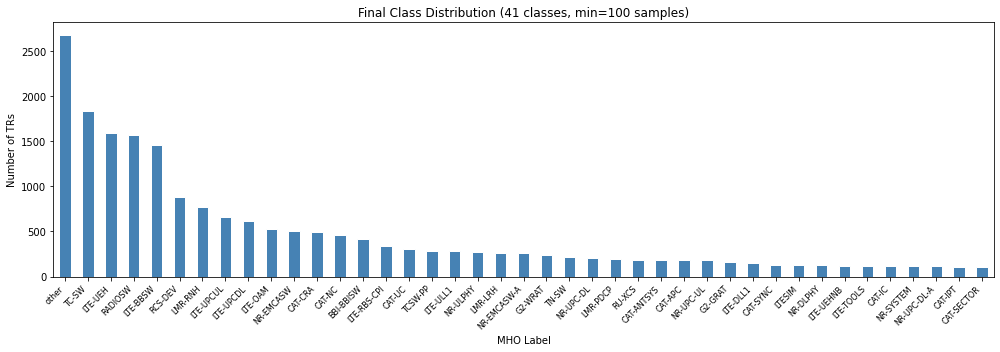

In [12]:
# Visualise final class distribution after merging
final_counts = df['target'].value_counts()

fig, ax = plt.subplots(figsize=(14, 5))
final_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f'Final Class Distribution ({df["target"].nunique()} classes, min={MIN_SAMPLES} samples)')
ax.set_xlabel('MHO Label')
ax.set_ylabel('Number of TRs')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

---
## Step 3: Exploratory Data Analysis (EDA)

**What:** Visualize and summarize the data to inform feature engineering decisions.

**Why:** EDA answers questions that directly shape the pipeline:
- How imbalanced are the classes? → Decides `MIN_SAMPLES` threshold
- How long are Observation texts? → Decides `max_length` for transformers
- Are there temporal trends? → Motivates the temporal split option
- Which categorical columns have useful cardinality? → Decides what to one-hot
- What's the duplicate rate? → Validates deduplication was necessary

**How:** `matplotlib` and `seaborn` plots: bar charts of class counts, histograms
of text lengths, time-series of TR volume by month, `value_counts` of categorical
columns, duplicate rate statistics.

**Key findings to look for:**
- Top 5 classes hold ~40% of all TRs (heavy skew)
- Observation text ranges from 100 to 10,000+ characters
- TR volume varies by quarter (correlates with release cycles)
- `General.Superior MHO` has only 2–3 values (strong routing signal)


In [13]:
import seaborn as sns

# --- 3.1 Text field word count analysis ---
# Word count is more meaningful than character count for NLP
# This guides TF-IDF max_features and transformer max_length choices
text_cols = [
    'General.Heading',
    'Observation.Observation',
    'Answer.Answer'
]
print("Text field word count statistics:")
print(f"{'Column':<35} {'mean':>6} {'median':>7} {'max':>6} {'null%':>7}")
print('-' * 65)
for col in text_cols:
    wc = df[col].fillna('').str.split().str.len()
    null_pct = df[col].isna().mean() * 100
    print(f"{col:<35} {wc.mean():>6.0f} {wc.median():>7.0f} {wc.max():>6} {null_pct:>6.1f}%")

Text field word count statistics:
Column                                mean  median    max   null%
-----------------------------------------------------------------
General.Heading                         11      10     39    0.0%
Observation.Observation               1312     760 120755    0.1%
Answer.Answer                          212     162  10746    0.2%


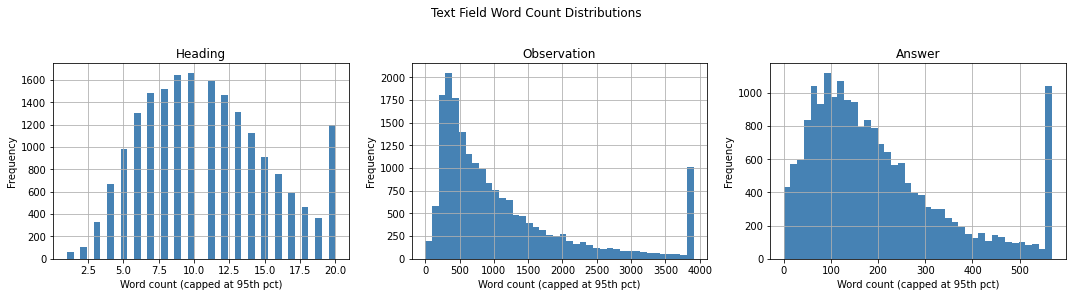

In [14]:
# --- 3.2 Text length distribution plots ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, text_cols):
    wc = df[col].fillna('').str.split().str.len()
    # Cap at 95th percentile for readability
    cap = int(wc.quantile(0.95))
    wc.clip(upper=cap).hist(bins=40, ax=ax, color='steelblue', edgecolor='none')
    ax.set_title(col.split('.')[-1])
    ax.set_xlabel('Word count (capped at 95th pct)')
    ax.set_ylabel('Frequency')
plt.suptitle('Text Field Word Count Distributions', y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# --- 3.3 Categorical feature distributions ---
# These will be used as structured features alongside text
cat_features = [
    'General.Submitter priority',
    'General.Superior MHO',
    'Observation.Fault type',
    'Analysis.Fault type',
    'Improvement.Type explanation'
]
for col in cat_features:
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(df[col].value_counts().to_string())


General.Submitter priority (3 unique values):
B    12853
C     3422
A     3281

General.Superior MHO (15 unique values):
LTE-MS-RBS     15995
BBSUPER         1933
BBI-SUPER        421
ERS-RADIO        259
ERS-BI           244
DURA-TOOLS       235
CPP-SUPER        160
EXTERNTOOLS      118
TTRD-SUPER        44
CBASWCOMP         32
BTS-SUPER         17
ENM-SUPER          6
3G-SUPERIOR        4
EAB-SGSNSUP        4
SF-SW              1

Observation.Fault type (12 unique values):
RESTART/CRASH      1576
OTHER              1100
KPI                 660
CELLDISABLED        437
MH General          384
General             362
ALARM               341
COUNTERS&EVENTS     184
OAM                 140
UPGRADE             119
CPI                  74
TOOLS                41

Analysis.Fault type (11 unique values):
Programming or systemization fault         223
Expected behavior                           24
Works with later version of SW              13
Not yet implemented                         12
No

In [16]:
# --- 3.4 Duplicate TR statistics ---
# README warns about duplicates — understand their prevalence
dup_col = 'General.Is duplicate TR'
print(f"Is duplicate TR distribution:")
print(df[dup_col].value_counts().to_string())
print(f"\nDuplicate TR rate: {(df[dup_col] == True).mean()*100:.1f}%")
print("\nNote: duplicate TRs still contain valid Observation text")
print("but their Answer.Answer may be empty (solved under the primary TR).")

Is duplicate TR distribution:
False    16250
True      3306

Duplicate TR rate: 16.9%

Note: duplicate TRs still contain valid Observation text
but their Answer.Answer may be empty (solved under the primary TR).


Date range: 2017-07-25 00:00:00 to 2021-09-02 00:00:00


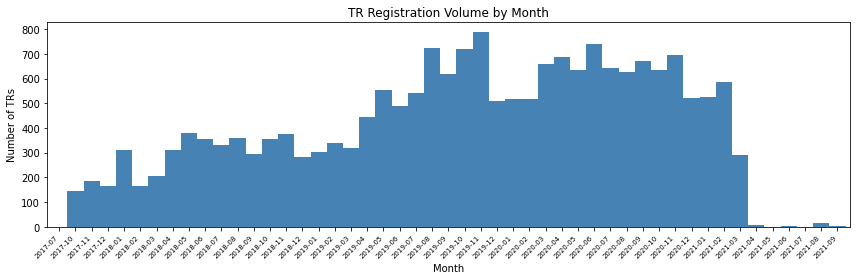

In [17]:
# --- 3.5 Temporal distribution ---
# Check if TRs are spread over time — important for avoiding temporal leakage
df['register_date'] = pd.to_datetime(df['TR History Register.Register date'], errors='coerce')
print(f"Date range: {df['register_date'].min()} to {df['register_date'].max()}")

fig, ax = plt.subplots(figsize=(12, 4))
df['register_date'].dt.to_period('M').value_counts().sort_index().plot(
    kind='bar', ax=ax, color='steelblue', edgecolor='none', width=1.0)
ax.set_title('TR Registration Volume by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Number of TRs')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

In [18]:
# --- 3.6 Routing time analysis ---
# Routing time features could be predictive (fast routing = well-known issue type)
time_cols = ['routing_time', 'routing_waiting_time', 'total_routing_time', 'total_time']
print("Routing time statistics (minutes):")
print(df[time_cols].describe().round(1).to_string())

Routing time statistics (minutes):
       routing_time  routing_waiting_time  total_routing_time  total_time
count       19556.0               19553.0             19556.0     19556.0
mean         4128.3                1029.8             51420.4     75034.7
std         24129.1                2203.7             92656.5     96935.9
min             0.0                   0.0                 0.0         8.2
25%           285.0                  80.1              9680.5     22569.2
50%          1199.0                 396.2             23844.0     50028.9
75%          3824.4                1204.0             55441.7     89232.0
max       1500579.9               99491.2           1890408.6   1768059.0


---
## Step 4: Feature Engineering

**What:** Transform raw CSV columns into the numeric feature matrix that the
model will train on.

**Why:** Models only understand numbers. Text must become TF-IDF vectors.
Categories must become one-hot vectors. The quality of this transformation
determines the ceiling of model performance — no model can learn patterns that
aren't encoded in its input.

**How — per-section TF-IDF (the key innovation):**

Instead of one TF-IDF over concatenated text, we fit **separate vectorizers**
for four sections of the TR:

| Section | Budget | Content | Cleaning |
|---|---|---|---|
| heading | 20% | `General.Heading` | alpha-only |
| effect | 45% | Observation section 1 EFFECT | alpha-only |
| config | 15% | Observation section 2.2 Configuration Data | **alphanumeric** (preserves `BB6630`, `21.Q3`) |
| cause | 20% | Answer CAUSE OF FAULT (training only) | alpha-only |

This lets the model weight the same word differently depending on where it
appears: `restart` in section 1 (the symptom) has a different TF-IDF weight
than `restart` in section 3 (the workaround).

**Additional feature groups:**
- Ordinal: Submitter priority (A=1, B=2, C=3) → scaled
- Categorical: Superior MHO + Fault type → one-hot encoded
- All fit on training data only, then applied to val/test (no leakage)

**N-grams:** In `fast` mode, only unigrams (single words). In `balanced`/`full`,
bigrams are added — word pairs like `cell_disabled`, `ri_link`, `cold_restart`
that carry stronger routing signal than either word alone.


---
## Step 4b: Engineered Features

**What:** Derive new numeric and categorical features from existing CSV columns
that TF-IDF cannot capture.

**Why:** TF-IDF captures word presence but misses structured information like
hardware board type, software release version, routing history, and duplicate
patterns. These carry independent routing signal.

**How — two categories:**

### A. Transformed Features (information already in the CSV, not yet encoded)

| Feature | Source | Signal |
|---|---|---|
| `flag_crash`, `flag_alarm`, etc. | Regex on Observation text | Symptom type → team |
| `board_type` (BB6630, AIR3239, ...) | Regex extraction | Hardware → team mapping |
| `sw_release` (21.Q3, 22.Q1, ...) | Regex extraction | Release → active team |
| `log_routing_time`, `auto_routed` | Routing columns | Fast routing = known pattern |
| `is_duplicate`, `num_duplicates` | Duplicate TR fields | Widespread issues cluster around specific teams |
| `rstate_major`, `cross_component` | Product hierarchy | Cross-component faults → integration teams |

### B. Genuinely New Features (external knowledge)

| Feature | Source | Signal |
|---|---|---|
| `prod_family`, `prod_gen`, `prod_tech` | Ericsson product catalog mapping | Product number → hardware family |
| `alarm_category`, `alarm_severity` | 3GPP TS 32.111 alarm mapping | Alarm text → standardized category |

All numeric features are StandardScaled; all categorical features are
OneHotEncoded with `handle_unknown='ignore'`.


In [19]:
# === A. TRANSFORMED FEATURES FROM EXISTING CSV COLUMNS ===

# --- A1. Keyword flags ---
# Binary features extracted via regex from Observation text
# Each flag directly encodes a known fault category signal
obs = df['Observation.Observation'].fillna('')

df['flag_crash']        = obs.str.contains(r'crash|pmd|core.?dump|program.?restart', case=False, regex=True).astype(int)
df['flag_alarm']        = obs.str.contains(r'\bAL\b|alarm', case=False, regex=True).astype(int)
df['flag_cell_disabled']= obs.str.contains(r'cell.*disabled|disabled.*cell|CELLDISABLED', case=False, regex=True).astype(int)
df['flag_restart']      = obs.str.contains(r'restart|reboot|cold.?start|warm.?start', case=False, regex=True).astype(int)
df['flag_upgrade']      = obs.str.contains(r'upgrade|UP\s+\d{2}|R\d{2}[A-Z]\d+', case=False, regex=True).astype(int)
df['flag_race_cond']    = obs.str.contains(r'race.?condition|deadlock|mutex|synchroni', case=False, regex=True).astype(int)
df['flag_log_traces']   = obs.str.contains(r'\d{4}-\d{2}-\d{2}\s+\d{2}:\d{2}', regex=True).astype(int)
df['flag_coli_output']  = obs.str.contains(r'coli>|OFFLINE_', regex=True).astype(int)

flag_cols = [c for c in df.columns if c.startswith('flag_')]
print('Keyword flag distributions:')
print(df[flag_cols].mean().round(3).to_string())

Keyword flag distributions:
flag_crash            0.424
flag_alarm            0.338
flag_cell_disabled    0.125
flag_restart          0.536
flag_upgrade          0.964
flag_race_cond        0.172
flag_log_traces       0.593
flag_coli_output      0.303


In [20]:
# --- A2. Board type extracted from Observation text ---
# Board type is a strong routing signal: certain boards are owned by specific teams
# e.g. BB6630/BB6648 -> baseband SW teams, AIR/IRU/RRU -> radio teams
df['board_type'] = obs.str.extract(r'(BB\d{4}|AIR\d{4}|IRU\d{4}|RRU\d{4}|RDS\w+)', expand=False)
df['board_type'] = df['board_type'].fillna('unknown')

print('Board type distribution (top 10):')
print(df['board_type'].value_counts().head(10).to_string())

Board type distribution (top 10):
unknown    10132
BB6630      1132
AIR6488      860
BB5216       854
RRU2212      662
RRU4415      655
BB6648       557
RRU4449      521
AIR3246      250
AIR3239      241


In [21]:
# --- A3. SW release quarter extracted from Observation text ---
# Release quarter correlates with which teams are active on fixes
# e.g. 21.Q1, 21.Q3.2
df['sw_release'] = obs.str.extract(r'(\d{2}\.Q\d(?:\.\d)?)', expand=False)
df['sw_release'] = df['sw_release'].fillna('unknown')

print('SW release distribution (top 10):')
print(df['sw_release'].value_counts().head(10).to_string())

SW release distribution (top 10):
unknown    7546
19.Q4      1318
19.Q2      1087
20.Q2      1043
20.Q4      1034
20.Q1       908
20.Q3       817
18.Q4       787
19.Q3       691
21.Q1       668


In [22]:
# --- A4. Temporal features from registration timestamp ---
# TRs filed late at night or weekends may come from field engineers (hardware issues)
# Quarter correlates with release cycles -> specific teams busier
df['register_dt'] = pd.to_datetime(df['Registered'], errors='coerce')
df['hour_of_day']  = df['register_dt'].dt.hour.fillna(-1).astype(int)
df['day_of_week']  = df['register_dt'].dt.dayofweek.fillna(-1).astype(int)  # 0=Mon
df['reg_quarter']  = df['register_dt'].dt.quarter.fillna(-1).astype(int)
df['reg_year']     = df['register_dt'].dt.year.fillna(-1).astype(int)

print('Temporal feature sample:')
print(df[['hour_of_day','day_of_week','reg_quarter','reg_year']].describe().round(1).to_string())

Temporal feature sample:
       hour_of_day  day_of_week  reg_quarter  reg_year
count      19556.0      19556.0      19556.0   19556.0
mean          10.5          2.1          2.6    2019.3
std            5.6          1.5          1.1       0.9
min            0.0          0.0          1.0    2017.0
25%            7.0          1.0          2.0    2019.0
50%           10.0          2.0          3.0    2019.0
75%           14.0          3.0          4.0    2020.0
max           23.0          6.0          4.0    2021.0


In [23]:
# --- A5. Routing features ---
# Fast routing = well-known issue type (auto-router recognised the pattern)
# log transform reduces skew in routing_time distribution
df['log_routing_time'] = np.log1p(df['routing_time'].fillna(0))
df['waiting_ratio']    = (
    df['routing_waiting_time'].fillna(0) /
    (df['total_routing_time'].fillna(0) + 1)  # +1 avoids division by zero
)
# routed flag: was TR automatically routed? Strong signal for known patterns
df['auto_routed'] = (df['routed'] == True).astype(int)

print('Routing feature sample:')
print(df[['log_routing_time','waiting_ratio','auto_routed']].describe().round(3).to_string())

Routing feature sample:
       log_routing_time  waiting_ratio  auto_routed
count         19556.000      19556.000    19556.000
mean              6.709          0.183        0.154
std               2.113         10.698        0.361
min               0.000          0.000        0.000
25%               5.656          0.002        0.000
50%               7.090          0.016        0.000
75%               8.249          0.069        0.000
max              14.221       1494.183        1.000


In [24]:
# --- A6. Duplicate TR features ---
df['is_duplicate']  = (df['General.Is duplicate TR'] == True).astype(int)
# Count how many duplicate TRs this TR has (primary TRs with many duplicates = widespread issue)
df['num_duplicates'] = df['General.Duplicate TRs'].str.count(r'H[A-Z]\d+').fillna(0).astype(int)

print(f"is_duplicate rate   : {df['is_duplicate'].mean()*100:.1f}%")
print(f"num_duplicates stats:\n{df['num_duplicates'].describe().round(2).to_string()}")

is_duplicate rate   : 16.9%
num_duplicates stats:
count    19556.00
mean         0.12
std          0.33
min          0.00
25%          0.00
50%          0.00
75%          0.00
max          1.00


In [25]:
# --- A7. Product hierarchy features ---
# R-State major version indicates SW generation (R24 vs R37 etc.)
df['rstate_major'] = (
    df['Faulty product.Product no & R-State']
    .str.extract(r'R(\d+)', expand=False)
)
df['rstate_major'] = pd.to_numeric(df['rstate_major'], errors='coerce').fillna(-1)

# Cross-component fault: faulty product differs from node-level product
# Indicates the fault crossed component boundaries -> harder to route
df['cross_component'] = (
    df['Faulty product.Product no'].fillna('') !=
    df['Node level.Product no'].fillna('')
).astype(int)

print(f"rstate_major stats:\n{df['rstate_major'].describe().round(1).to_string()}")
print(f"\ncross_component rate: {df['cross_component'].mean()*100:.1f}%")

rstate_major stats:
count    19556.0
mean         3.1
std         18.3
min         -1.0
25%         -1.0
50%         -1.0
75%         -1.0
max        999.0

cross_component rate: 99.5%


In [26]:
# === B. GENUINELY NEW FEATURES (external knowledge not in the CSV) ===

# --- B1. Ericsson Product Catalog mapping ---
# Maps product numbers to product family, generation and technology type
# Source: publicly available Ericsson product documentation
# This turns a cryptic product number into meaningful categorical features
#
# Example mapping (extend with real catalog data):
# KDU137848 -> Baseband 6630, G2, NR
# KDU1370015 -> Baseband 6648, G2, LTE+NR
# KRC161842  -> IRU1649, Radio, NR
# KRD901206  -> AIR6449, Radio, NR

PRODUCT_CATALOG = {
    # product_no_prefix -> (family, generation, technology)
    'KDU137848' : ('Baseband_6630', 'G2', 'NR'),
    'KDU1370015': ('Baseband_6648', 'G2', 'LTE_NR'),
    'KDU137925' : ('Baseband_5216', 'G2', 'LTE'),
    'KRC161842' : ('IRU1649',       'G3', 'NR'),
    'KRC161549' : ('RRUS2217',      'G2', 'LTE'),
    'KRD901206' : ('AIR6449',       'G3', 'NR'),
    'KRC161756' : ('Radio4449',     'G3', 'NR'),
    'KRC161707' : ('RRU88430',      'G2', 'LTE'),
}

def lookup_product_catalog(product_no):
    """Look up product family/generation/technology from product number prefix."""
    if pd.isna(product_no):
        return ('unknown', 'unknown', 'unknown')
    # Try matching on the first part of the product number
    clean = str(product_no).replace(' ', '').replace('/', '')
    for prefix, info in PRODUCT_CATALOG.items():
        if clean.startswith(prefix):
            return info
    return ('unknown', 'unknown', 'unknown')

catalog_info = df['Faulty product.Product no'].apply(lookup_product_catalog)
df['prod_family'] = catalog_info.apply(lambda x: x[0])
df['prod_gen']    = catalog_info.apply(lambda x: x[1])
df['prod_tech']   = catalog_info.apply(lambda x: x[2])

print('Product catalog feature distributions:')
for col in ['prod_family', 'prod_gen', 'prod_tech']:
    print(f'\n{col}:')
    print(df[col].value_counts().to_string())

Product catalog feature distributions:

prod_family:
unknown          19444
Baseband_6630       46
Baseband_6648       37
Baseband_5216       20
RRU88430             6
RRUS2217             2
Radio4449            1

prod_gen:
unknown    19444
G2           111
G3             1

prod_tech:
unknown    19444
NR            47
LTE_NR        37
LTE           28


In [27]:
# --- B2. 3GPP Standard Alarm Code mapping ---
# Maps alarm names found in Observation text to official 3GPP category and severity
# Source: 3GPP TS 32.111 and TS 28.532 (publicly available)
# This gives structured signal from unstructured alarm log text

GPP_ALARM_MAP = {
    # alarm_name_pattern -> (3gpp_category, severity_tier)
    'License Key File Fault'          : ('LicenseManagement',  'critical'),
    'Autonomous Mode Activated'       : ('LicenseManagement',  'major'),
    'Emergency Unlock'                : ('LicenseManagement',  'major'),
    'Resource Activation Timeout'     : ('RadioResource',      'major'),
    'SW Error'                        : ('Software',           'minor'),
    'Cell.*[Dd]isabled'               : ('RadioResource',      'major'),
    'RI.*[Ll]ink.*[Dd]own'            : ('Transport',          'major'),
    'CPRI.*[Ff]ault'                  : ('Transport',          'major'),
    'Synchronization.*[Ll]ost'        : ('Synchronization',    'critical'),
}

def extract_3gpp_alarm_features(text):
    """Return (category, severity) of the first matched 3GPP alarm in text."""
    if pd.isna(text):
        return ('none', 'none')
    for pattern, (cat, sev) in GPP_ALARM_MAP.items():
        if re.search(pattern, text, re.IGNORECASE):
            return (cat, sev)
    return ('unknown', 'unknown')

alarm_features = df['Observation.Observation'].apply(extract_3gpp_alarm_features)
df['alarm_category'] = alarm_features.apply(lambda x: x[0])
df['alarm_severity'] = alarm_features.apply(lambda x: x[1])

print('3GPP alarm category distribution:')
print(df['alarm_category'].value_counts().to_string())
print('\n3GPP alarm severity distribution:')
print(df['alarm_severity'].value_counts().to_string())

3GPP alarm category distribution:
unknown              16778
RadioResource         1908
Software               478
Transport              192
LicenseManagement      166
Synchronization         24
none                    10

3GPP alarm severity distribution:
unknown     16778
major        2158
minor         478
critical      132
none           10


In [28]:
# --- B3. Domain-adapted embeddings (BERT-for-Patents / SciBERT) ---
# Instead of generic DistilBERT (trained on Wikipedia), use a model
# pre-trained on technical/patent text which is closer to TR language.
# This is used in Step 9 as an alternative to distilbert-base-uncased.
#
# Options (all available on HuggingFace Hub):
#   'allenai/scibert_scivocab_uncased'  - trained on scientific papers
#   'anferico/bert-for-patents'         - trained on patent text
#   'distilbert-base-uncased'           - generic baseline (current)
#
# To switch model in Step 9, change MODEL_NAME below:

DOMAIN_MODEL_OPTIONS = {
    'generic'  : 'distilbert-base-uncased',
    'scibert'  : 'allenai/scibert_scivocab_uncased',
    'patents'  : 'anferico/bert-for-patents',
}

# Set which model to use for Step 9
# Change to 'scibert' or 'patents' to use domain-adapted embeddings
SELECTED_DOMAIN_MODEL = 'generic'
TRANSFORMER_MODEL_NAME = DOMAIN_MODEL_OPTIONS[SELECTED_DOMAIN_MODEL]

print(f'Selected transformer model: {TRANSFORMER_MODEL_NAME}')
print('Change SELECTED_DOMAIN_MODEL to scibert or patents for domain-adapted embeddings.')

Selected transformer model: distilbert-base-uncased
Change SELECTED_DOMAIN_MODEL to scibert or patents for domain-adapted embeddings.


In [29]:
# Define column lists for new features
# Actual encoding happens in cell-21 after the train/val/test split

new_num_cols = [
    'flag_crash', 'flag_alarm', 'flag_cell_disabled', 'flag_restart',
    'flag_upgrade', 'flag_race_cond', 'flag_log_traces', 'flag_coli_output',
    'log_routing_time', 'waiting_ratio', 'auto_routed',
    'is_duplicate', 'num_duplicates',
    'rstate_major', 'cross_component',
    'hour_of_day', 'day_of_week', 'reg_quarter', 'reg_year'
]

new_cat_cols = [
    'board_type', 'sw_release',
    'prod_family', 'prod_gen', 'prod_tech',
    'alarm_category', 'alarm_severity'
]

print(f'Defined {len(new_num_cols)} new numeric feature columns')
print(f'Defined {len(new_cat_cols)} new categorical feature columns')
print('Encoding will happen in Step 4 after the train/val/test split.')


Defined 19 new numeric feature columns
Defined 7 new categorical feature columns
Encoding will happen in Step 4 after the train/val/test split.


In [30]:
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------------
# SPLIT_MODE controls how the data is divided.
#
# 'random_stratified' — 60/20/20 random stratified on the target.
#   Good class balance per split. This is the DIAGNOSTIC baseline.
#
# 'temporal'          — earliest 60% -> train, middle 20% -> val,
#   latest 20% -> test, based on the Registered timestamp.
#   This simulates deployment: the model at inference time is trained
#   on past TRs and judged on future ones, so it captures vocabulary
#   drift and team reorganization. This is the HONEST baseline.
#
# In practice, running both and comparing is most informative. If
# temporal accuracy is much lower than random, the model has been
# relying on vocabulary that doesn't generalize forward in time.
# ------------------------------------------------------------------
SPLIT_MODE = 'random_stratified'  # 'random_stratified' | 'temporal'

if SPLIT_MODE == 'random_stratified':
    train_df, temp_df = train_test_split(
        df, test_size=0.4, random_state=42, stratify=df['target'])
    val_df, test_df   = train_test_split(
        temp_df, test_size=0.5, random_state=42, stratify=temp_df['target'])

elif SPLIT_MODE == 'temporal':
    # Parse the Registered column into a datetime for ordering.
    reg = pd.to_datetime(df['Registered'].astype(str).str.replace(' - ', ' '),
                         errors='coerce')
    df_sorted = df.assign(_reg=reg).sort_values('_reg').drop(columns='_reg').reset_index(drop=True)
    n = len(df_sorted)
    i_tr = int(n * 0.6)
    i_va = int(n * 0.8)
    train_df = df_sorted.iloc[:i_tr].copy()
    val_df   = df_sorted.iloc[i_tr:i_va].copy()
    test_df  = df_sorted.iloc[i_va:].copy()

else:
    raise ValueError(f'Unknown SPLIT_MODE: {SPLIT_MODE!r}')

print(f'SPLIT_MODE = {SPLIT_MODE}')
print(f'Train : {len(train_df):>5} rows ({len(train_df)/len(df):.1%})')
print(f'Val   : {len(val_df):>5} rows ({len(val_df)/len(df):.1%})')
print(f'Test  : {len(test_df):>5} rows ({len(test_df)/len(df):.1%})')


SPLIT_MODE = random_stratified
Train : 11733 rows (60.0%)
Val   :  3911 rows (20.0%)
Test  :  3912 rows (20.0%)


---
### Data Contract: split consistency check

Before building any features, verify that every categorical input column
has values in val/test that also appear in train. A value in val that
wasn't in train (e.g. a rare `Superior MHO = 'SF-SW'`) would cause a
sklearn `LabelEncoder` to fail mid-pipeline. This check prints the
offenders up front so we can decide explicitly how to handle them —
usually by routing through `SafeLabelEncoder(strategy='warn')` which
remaps unseen values to an `unknown` bucket.


In [ ]:
# Input columns we'll encode or branch on downstream.
CONTRACT_COLS = [
    'General.Superior MHO',
    'Observation.Fault type',
    'General.Submitter priority',
]

_split_issues = assert_split_consistency(train_df, val_df, test_df, CONTRACT_COLS)


In [ ]:
# Text preprocessing helpers moved to cell-utils earlier in the notebook
# (clean_text, clean_text_keep_alphanum, extract_effect_section,
# extract_observation_sections, extract_cause_of_fault, build_text_column).
# Text columns are built in the next cell (cell-18) using those helpers.
print('cell-17: helpers moved to cell-utils; see cell-18 for text matrices')


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy.sparse import hstack, csr_matrix

# ------------------------------------------------------------------
# PER-SECTION TF-IDF on the Observation field
#
# Instead of one TF-IDF over concatenated text, we fit separate
# vectorizers for:
#   heading  — General.Heading (always available, short, high-signal)
#   effect   — Observation section 1 EFFECT (symptom summary)
#   config   — Observation section 2.2 Configuration Data (alphanumeric
#              preserved: board/SW tokens like 'BB6630', '21.Q3' carry
#              strong routing signal and would be destroyed by clean_text)
#   cause    — Answer CAUSE OF FAULT (training rows only)
#
# This lets a term like 'restart' get a different TF-IDF weight if it
# appears in the Effect section vs. Configuration Data vs. Workaround.
# ------------------------------------------------------------------

def _obs_sections(frame):
    secs = frame['Observation.Observation'].apply(extract_observation_sections)
    return pd.DataFrame(list(secs), index=frame.index)

print('Extracting Observation sections...')
train_obs = _obs_sections(train_df)
val_obs   = _obs_sections(val_df)
test_obs  = _obs_sections(test_df)

train_heading = train_df['General.Heading'].fillna('').apply(clean_text).tolist()
val_heading   = val_df['General.Heading'].fillna('').apply(clean_text).tolist()
test_heading  = test_df['General.Heading'].fillna('').apply(clean_text).tolist()

train_effect = train_obs['effect'].apply(clean_text).tolist()
val_effect   = val_obs['effect'].apply(clean_text).tolist()
test_effect  = test_obs['effect'].apply(clean_text).tolist()

# Configuration Data keeps alphanumeric tokens.
train_config = train_obs['config'].apply(clean_text_keep_alphanum).tolist()
val_config   = val_obs['config'].apply(clean_text_keep_alphanum).tolist()
test_config  = test_obs['config'].apply(clean_text_keep_alphanum).tolist()

# Answer.CAUSE OF FAULT — training only. Val/test get empty strings so the
# vectorizer's vocabulary is usable at inference time (produces near-zero rows).
train_cause = train_df['Answer.Answer'].apply(extract_cause_of_fault).apply(clean_text).tolist()
val_cause   = [''] * len(val_df)
test_cause  = [''] * len(test_df)

# Size budget per section — splits the total CONFIG['max_features'] across sections.
_total = CONFIG['max_features']
_SECTIONS = {
    'heading': (int(_total * 0.20), train_heading, val_heading, test_heading),
    'effect' : (int(_total * 0.45), train_effect,  val_effect,  test_effect),
    'config' : (int(_total * 0.15), train_config,  val_config,  test_config),
    'cause'  : (int(_total * 0.20), train_cause,   val_cause,   test_cause),
}

section_vectorizers = {}
X_train_sections, X_val_sections, X_test_sections = [], [], []
for name, (budget, tr, va, te) in _SECTIONS.items():
    tv = TfidfVectorizer(
        max_features = max(budget, 100),
        stop_words   = 'english',
        ngram_range  = CONFIG['ngram_range'],
        min_df       = 2,
        max_df       = 0.95,
    )
    Xtr = tv.fit_transform(tr)
    Xva = tv.transform(va)
    Xte = tv.transform(te)
    section_vectorizers[name] = tv
    X_train_sections.append(Xtr); X_val_sections.append(Xva); X_test_sections.append(Xte)
    print(f'  {name:<8s}: {Xtr.shape[1]:>5} features')

X_train_text = hstack(X_train_sections).tocsr()
X_val_text   = hstack(X_val_sections).tocsr()
X_test_text  = hstack(X_test_sections).tocsr()

print(f'\nPer-section TF-IDF: {X_train_text.shape[1]} features total '
      f'(ngram={CONFIG["ngram_range"]})')

# Backward-compat single text list for cells that still expect it
# (SBERT encoder, duplicate-detection fallback, Step 9 transformer).
train_texts = build_text_column(train_df, use_answer=True)
val_texts   = build_text_column(val_df,   use_answer=False)
test_texts  = build_text_column(test_df,  use_answer=False)


In [ ]:
# --- Ordinal feature: Submitter priority ---
# A (highest) = 1, B = 2, C (lowest) = 3
# Missing priority encoded as 0 (unknown)
priority_map = {'A': 1, 'B': 2, 'C': 3}

def encode_priority(dataframe):
    return (dataframe['General.Submitter priority']
            .map(priority_map).fillna(0).values.reshape(-1, 1))

# StandardScaler: zero mean, unit variance
# Fit on training data only
scaler = StandardScaler()
X_train_ord = scaler.fit_transform(encode_priority(train_df))
X_val_ord   = scaler.transform(encode_priority(val_df))
X_test_ord  = scaler.transform(encode_priority(test_df))

print(f"Priority feature: mean={scaler.mean_[0]:.2f}, std={scaler.scale_[0]:.2f}")

In [ ]:
# --- Target label encoding (SafeLabelEncoder, strategy='raise') ---
# Use 'raise' so that unseen TARGET labels in val/test are NEVER silently
# remapped — a silent remap there would hide an upstream bug in the
# rare-class merge or split logic.
le = SafeLabelEncoder(strategy='raise')
y_train = le.fit_transform(train_df['target'])
y_val   = le.transform(val_df['target'])
y_test  = le.transform(test_df['target'])

# --- Categorical input features: Superior MHO + Observation Fault type ---
# OneHotEncoder with handle_unknown='ignore' handles unseen categories natively
# (they produce all-zero rows), so no SafeLabelEncoder needed here.
cat_cols = ['General.Superior MHO', 'Observation.Fault type']
ohe = OneHotEncoder(sparse=True, handle_unknown='ignore')
X_train_cat = ohe.fit_transform(train_df[cat_cols].fillna('unknown'))
X_val_cat   = ohe.transform(val_df[cat_cols].fillna('unknown'))
X_test_cat  = ohe.transform(test_df[cat_cols].fillna('unknown'))

print(f'Target classes : {len(le.classes_)} (SafeLabelEncoder, strategy=raise)')
print(f'OneHot dim     : {X_train_cat.shape[1]}')


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from scipy.sparse import hstack, csr_matrix

# --- Base feature combination ---
X_train = hstack([X_train_text, csr_matrix(X_train_ord), X_train_cat])
X_val   = hstack([X_val_text,   csr_matrix(X_val_ord),   X_val_cat])
X_test  = hstack([X_test_text,  csr_matrix(X_test_ord),  X_test_cat])

# --- New numeric features (fit on train only) ---
scaler_new = StandardScaler()
X_train_new_num = scaler_new.fit_transform(train_df[new_num_cols].fillna(0))
X_val_new_num   = scaler_new.transform(val_df[new_num_cols].fillna(0))
X_test_new_num  = scaler_new.transform(test_df[new_num_cols].fillna(0))

# --- New categorical features (fit on train only) ---
ohe_new = OneHotEncoder(sparse=True, handle_unknown='ignore')
X_train_new_cat = ohe_new.fit_transform(train_df[new_cat_cols].fillna('unknown'))
X_val_new_cat   = ohe_new.transform(val_df[new_cat_cols].fillna('unknown'))
X_test_new_cat  = ohe_new.transform(test_df[new_cat_cols].fillna('unknown'))

# --- Encode target labels ---
le = LabelEncoder()
y_train = le.fit_transform(train_df['target'])
y_val   = le.transform(val_df['target'])
y_test  = le.transform(test_df['target'])

print(f'Base feature matrix     : {X_train.shape}')
print(f'  TF-IDF dims           : {X_train_text.shape[1]}')
print(f'  Ordinal dims          : {X_train_ord.shape[1]}')
print(f'  Categorical dims      : {X_train_cat.shape[1]}')
print(f'New numeric dims        : {X_train_new_num.shape[1]}')
print(f'New categorical dims    : {X_train_new_cat.shape[1]}')
print(f'Number of target classes: {len(le.classes_)}')
print(f'Classes: {list(le.classes_)}')


---
## Step 4d: SMOTE Oversampling (Optional)

**SMOTE** (Synthetic Minority Over-sampling Technique) generates synthetic training
samples for minority classes by interpolating between existing samples:
```
new_sample = sample_A + λ × (sample_B - sample_A),  λ ∈ [0, 1]
```

### When to Use
Enable SMOTE only if the classification report in Step 10 shows very low recall
(< 0.3) for minority classes AND `class_weight='balanced'` in Step 7 is insufficient.

### Why SMOTE is Optional Here
For this project, explicit imbalance handling is likely **not required** because:
- Rare classes (< 100 samples) are already merged into `other` in Step 2
- `class_weight='balanced'` in GridSearchCV (Step 7) handles remaining imbalance
- TF-IDF features are highly discriminative — each team uses distinct vocabulary,
  so the model can learn team patterns even from fewer samples
- SMOTE interpolates between sparse TF-IDF vectors, producing unrealistic synthetic
  text representations that may not improve generalisation
- The `other` class has poor F1 due to heterogeneity, not imbalance — SMOTE cannot fix this

### SMOTE vs class_weight='balanced'
| | SMOTE | class_weight='balanced' |
|---|---|---|
| Mechanism | Generates synthetic samples | Upweights minority samples in loss |
| Memory | High (~3.5GB for 20k TF-IDF) | None |
| Risk for TF-IDF | Synthetic vectors may be unrealistic | None |
| Recommended | Only if class_weight insufficient | Always try first |

Set `APPLY_SMOTE = True` below to enable. Default is `False`.


In [38]:
from imblearn.over_sampling import SMOTE

# Set to True to apply SMOTE oversampling on the training set.
# Requires: pip install imbalanced-learn
APPLY_SMOTE = False

# Safety threshold: densifying a sparse matrix with more features than this
# would use >~2 GB of RAM for ~13k rows. Raise SMOTE_MAX_DENSE_FEATURES only
# if you know you have the memory headroom.
SMOTE_MAX_DENSE_FEATURES = 10_000

if APPLY_SMOTE:
    n_rows, n_feat = X_train.shape
    mem_gb = n_rows * n_feat * 8 / 1e9
    print(f'X_train is {n_rows} x {n_feat}. Dense conversion would use '
          f'~{mem_gb:.1f} GB.')
    if n_feat > SMOTE_MAX_DENSE_FEATURES:
        raise MemoryError(
            f'SMOTE requires dense input. {n_feat} features exceeds the '
            f'{SMOTE_MAX_DENSE_FEATURES} safety threshold. Either reduce '
            f'CONFIG["max_features"], apply SMOTE to X_train_text only, '
            f'or raise SMOTE_MAX_DENSE_FEATURES after checking RAM.'
        )
    print(f'Before SMOTE — train size: {n_rows}')
    print('Class distribution before SMOTE:')
    print(pd.Series(y_train).value_counts().sort_index().to_string())

    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train.toarray(), y_train)
    X_train_smote = csr_matrix(X_train_smote)

    print(f'\nAfter SMOTE — train size: {X_train_smote.shape[0]}')
    print('Class distribution after SMOTE:')
    print(pd.Series(y_train_smote).value_counts().sort_index().to_string())

    X_train = X_train_smote
    y_train = y_train_smote
    print('\nX_train and y_train replaced with SMOTE-augmented data.')
else:
    print('SMOTE not applied. Set APPLY_SMOTE = True to enable.')
    print('Class imbalance handled via class_weight="balanced" in Step 7 instead.')


SMOTE not applied. Set APPLY_SMOTE = True to enable.
Class imbalance handled via class_weight="balanced" in Step 7 instead.


---
## Step 4c: TF-IDF + SBERT Hybrid Features

The best no-GPU text representation strategy is to **combine TF-IDF with SBERT embeddings**:

- **TF-IDF** captures rare domain-specific keywords (e.g. 'iepcsi', 'rpcSc', 'DLSR') with high precision
- **SBERT** captures semantic meaning and context ('cell disabled' ≈ 'radio resource unavailable')
- **Hybrid** = hstack(TF-IDF sparse matrix, SBERT dense matrix) — gets the best of both

No fine-tuning required — SBERT is used as a frozen feature extractor.
Install with: `pip install sentence-transformers`

In [39]:
# --- SBERT encoding (controlled by RUN_MODE) ---
# fast: skipped. balanced/full: enabled (~20-40 min on CPU).
SBERT_AVAILABLE = False

if not CONFIG['use_sbert']:
    print(f'SBERT skipped (RUN_MODE={RUN_MODE}). Set RUN_MODE="balanced" or "full" to enable.')
else:
    try:
        from sentence_transformers import SentenceTransformer
        import torch
        sbert_device = 'cuda' if torch.cuda.is_available() else 'cpu'
        print(f'Loading SBERT: all-MiniLM-L6-v2 on {sbert_device}...')
        sbert_model = SentenceTransformer('all-MiniLM-L6-v2', device=sbert_device)
        SBERT_AVAILABLE = True
        print('Encoding train texts (~20-40 min on CPU)...')
        X_train_sbert = sbert_model.encode(
            train_texts, batch_size=32, show_progress_bar=True, convert_to_numpy=True)
        print('Encoding val texts...')
        X_val_sbert = sbert_model.encode(
            val_texts, batch_size=32, show_progress_bar=True, convert_to_numpy=True)
        print('Encoding test texts...')
        X_test_sbert = sbert_model.encode(
            test_texts, batch_size=32, show_progress_bar=True, convert_to_numpy=True)
        print(f'SBERT embedding shape: {X_train_sbert.shape}')
    except Exception as e:
        print(f'SBERT failed: {e}')
        print('Falling back to TF-IDF only.')


SBERT skipped (RUN_MODE=fast). Set RUN_MODE="balanced" or "full" to enable.


In [40]:
# --- Build TF-IDF + SBERT hybrid feature matrices ---
# Falls back to TF-IDF + structured features only if SBERT unavailable
from scipy.sparse import hstack, csr_matrix

if SBERT_AVAILABLE:
    X_train_hybrid = hstack([X_train_text, csr_matrix(X_train_sbert)])
    X_val_hybrid   = hstack([X_val_text,   csr_matrix(X_val_sbert)])
    X_test_hybrid  = hstack([X_test_text,  csr_matrix(X_test_sbert)])
    X_train_hybrid_full = hstack([
        X_train_text, csr_matrix(X_train_sbert),
        csr_matrix(X_train_ord), X_train_cat,
        csr_matrix(X_train_new_num), X_train_new_cat
    ])
    X_val_hybrid_full = hstack([
        X_val_text, csr_matrix(X_val_sbert),
        csr_matrix(X_val_ord), X_val_cat,
        csr_matrix(X_val_new_num), X_val_new_cat
    ])
    X_test_hybrid_full = hstack([
        X_test_text, csr_matrix(X_test_sbert),
        csr_matrix(X_test_ord), X_test_cat,
        csr_matrix(X_test_new_num), X_test_new_cat
    ])
    print(f'TF-IDF dims             : {X_train_text.shape[1]}')
    print(f'SBERT dims              : {X_train_sbert.shape[1]}')
    print(f'Hybrid (text+SBERT)     : {X_train_hybrid.shape[1]}')
    print(f'Hybrid full (all feats) : {X_train_hybrid_full.shape[1]}')
else:
    # No SBERT — use TF-IDF + structured features as the 'hybrid'
    X_train_hybrid      = X_train_text
    X_val_hybrid        = X_val_text
    X_test_hybrid       = X_test_text
    X_train_hybrid_full = hstack([
        X_train_text, csr_matrix(X_train_ord), X_train_cat,
        csr_matrix(X_train_new_num), X_train_new_cat
    ])
    X_val_hybrid_full   = hstack([
        X_val_text, csr_matrix(X_val_ord), X_val_cat,
        csr_matrix(X_val_new_num), X_val_new_cat
    ])
    X_test_hybrid_full  = hstack([
        X_test_text, csr_matrix(X_test_ord), X_test_cat,
        csr_matrix(X_test_new_num), X_test_new_cat
    ])
    print('SBERT not available — using TF-IDF + structured features only')
    print(f'TF-IDF dims             : {X_train_text.shape[1]}')
    print(f'Hybrid full (no SBERT)  : {X_train_hybrid_full.shape[1]}')


SBERT not available — using TF-IDF + structured features only
TF-IDF dims             : 3000
Hybrid full (no SBERT)  : 3315


---
## Step 5: Baseline Model Comparison

**What:** Train a shortlist of candidate models and compare their validation
accuracy and macro F1.

**Why:** Before tuning, we need to know which model family works best for this
data. Running multiple candidates with the same features isolates the effect of
the algorithm from the effect of the features.

**How — 4 candidates with explicit roles:**

| Model | Role | Why this model |
|---|---|---|
| Logistic Regression | Calibrated baseline | Native probabilities for confidence routing; fast; interpretable |
| LinearSVC | High-accuracy contender | Best raw accuracy on sparse TF-IDF; must be Platt-scaled for confidence |
| Multinomial NB | Fast sanity check | If NB beats your tuned model, something is wrong with the pipeline |
| (Step 9) DistilBERT/SBERT | Transformer ceiling | Upper bound of what's achievable; expensive to run |

**Why linear models win for TF-IDF:**
- With 5k–20k sparse features, data is high-dimensional
- Different teams use distinct technical vocabulary → classes are often linearly separable
- Linear models scale as O(n × d); trees split one feature at a time (inefficient when 99% of features are zero)

**Metrics reported:** accuracy, macro F1, weighted F1, train-val gap, training time.
All computed via the unified `evaluate()` function.


In [41]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

# ------------------------------------------------------------------
# FOUR CANDIDATES, each with an explicit role:
#   Logistic Regression   — calibrated baseline, natively gives probabilities
#   LinearSVC             — typically best raw accuracy on TF-IDF; must be
#                           Platt-scaled later for confidence routing
#   MultinomialNB         — weak but fast sanity check; TF-IDF only
#   Logistic Regression   — second instance on TF-IDF+All to isolate the
#   (hybrid features)       effect of engineered/SBERT features
#
# Slower / less-useful models (SGD, RF, MLP, XGBoost) are deferred to
# the 'sanity check' cell below; they rarely beat a tuned LinearSVC on
# sparse TF-IDF and their presence in the main table dilutes focus.
# ------------------------------------------------------------------

results = {}
trained_models = {}

def _run(name, model, Xtr, Xva, feat_label):
    run_name = f'{name} [{feat_label}]'
    print(f'Training {run_name}...', end=' ', flush=True)
    t0 = time.time()
    m = model.__class__(**model.get_params()).fit(Xtr, y_train)
    row = evaluate(m, Xva, y_val, run_name, y_train=y_train, X_train=Xtr)
    row['time_s']   = time.time() - t0
    row['features'] = feat_label
    results[run_name]        = row
    trained_models[run_name] = m
    print(f'train={row["train_accuracy"]:.3f}  val={row["accuracy"]:.3f}  '
          f'macroF1={row["macro_f1"]:.3f}  ({row["time_s"]:.1f}s)')

_run('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42, C=1.0),
     X_train_text,        X_val_text,        'TF-IDF only')
_run('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42, C=1.0),
     X_train_hybrid_full, X_val_hybrid_full, 'TF-IDF + All')
_run('Linear SVM', LinearSVC(random_state=42, max_iter=2000, C=1.0),
     X_train_text,        X_val_text,        'TF-IDF only')
_run('Linear SVM', LinearSVC(random_state=42, max_iter=2000, C=1.0),
     X_train_hybrid_full, X_val_hybrid_full, 'TF-IDF + All')
_run('Multinomial NB', MultinomialNB(),
     X_train_text,        X_val_text,        'TF-IDF only')

results_df = pd.DataFrame(results).T.sort_values('accuracy', ascending=False)
_cols = ['accuracy', 'macro_f1', 'weighted_f1', 'train_accuracy', 'gap', 'time_s', 'features']
print(f'\n=== Baseline Model Comparison (RUN_MODE={RUN_MODE}) ===')
print(results_df[_cols].round(4).to_string())

# Rename 'accuracy' column to 'val_acc' for backward compat with cell-5b-3,
# cell-27, cell-35 which reference results_df.loc[..., 'val_acc'].
results_df = results_df.rename(columns={'accuracy': 'val_acc'})
best_name = results_df.index[0]
print(f'\nBest baseline: {best_name}  val_acc={results_df.loc[best_name, "val_acc"]:.4f}  '
      f'macro_f1={results_df.loc[best_name, "macro_f1"]:.4f}')

# Optional deeper sanity check — triggered only in slow_models mode.
if CONFIG.get('slow_models', False):
    print('\n--- slow-models sanity check (RF, MLP) ---')
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.neural_network import MLPClassifier
    _run('Random Forest', RandomForestClassifier(
             n_estimators=100, random_state=42, n_jobs=-1, max_features='sqrt'),
         X_train_hybrid_full, X_val_hybrid_full, 'TF-IDF + All')
    _run('MLP', MLPClassifier(hidden_layer_sizes=(128,), max_iter=200,
                              random_state=42, early_stopping=True),
         X_train_hybrid_full, X_val_hybrid_full, 'TF-IDF + All')
    # Refresh results_df with the new rows
    results_df = pd.DataFrame(results).T.sort_values('accuracy', ascending=False).rename(
        columns={'accuracy': 'val_acc'})
    best_name = results_df.index[0]
    print(f'Best after sanity: {best_name}  val_acc={results_df.loc[best_name, "val_acc"]:.4f}')


Training Logistic Regression [TF-IDF only]... train=0.783  val=0.333  macroF1=0.208  (12.2s)
Training Logistic Regression [TF-IDF + All]... train=0.862  val=0.452  macroF1=0.357  (51.3s)
Training Linear SVM [TF-IDF only]... train=0.954  val=0.303  macroF1=0.234  (2.1s)
Training Linear SVM [TF-IDF + All]... train=0.979  val=0.418  macroF1=0.346  (23.1s)
Training Multinomial NB [TF-IDF only]... train=0.522  val=0.329  macroF1=0.167  (0.1s)

=== Baseline Model Comparison (RUN_MODE=fast) ===
                                    accuracy  macro_f1 weighted_f1 train_accuracy       gap     time_s      features
Logistic Regression [TF-IDF + All]  0.451547  0.356698    0.424348       0.862439  0.410892  51.264035  TF-IDF + All
Linear SVM [TF-IDF + All]           0.418052    0.3458    0.400974       0.979204  0.561152   23.08644  TF-IDF + All
Logistic Regression [TF-IDF only]   0.332907  0.207758    0.305087        0.78292  0.450013  12.219035   TF-IDF only
Multinomial NB [TF-IDF only]        0.3

---
## Step 5b: Hierarchical Classification

**What:** A two-stage classifier that exploits the natural label hierarchy.

**Why:** The MHO labels have a two-level structure already in the CSV:
- Level 1: `General.Superior MHO` (LTE-MS-RBS vs ERS-RADIO) — 2–3 classes
- Level 2: The specific team within that group

A hierarchical classifier prevents errors from crossing the LTE/Radio boundary.
If Stage 1 correctly identifies the TR as LTE, Stage 2 only considers LTE teams,
reducing confusion.

**How:**
- Stage 1: LinearSVC predicts Superior MHO (~99% accuracy, trivially easy)
- Stage 2: One LinearSVC per group, trained on that group's subset
- Fallback: if a group has no Stage 2 model, use the flat best model

**Unseen-class handling:** Val rows whose target class didn't appear in the
group's training set are excluded from per-group accuracy (tracked separately).
This avoids silently counting distribution mismatch as model error.

**Evaluated on both val and test sets** — included in the final comparison table.


In [42]:
from sklearn.pipeline import Pipeline

# --- Stage 1: Predict Superior MHO (input feature, 2 or 3 classes) ---
# Superior MHO is an input feature available at routing time. Rare values
# like 'SF-SW' may appear in val/test but not in train; SafeLabelEncoder
# with strategy='warn' handles them by remapping to an unknown bucket.
sup_mho_col = 'General.Superior MHO'

le_stage1 = SafeLabelEncoder(strategy='warn')
y_train_s1 = le_stage1.fit_transform(train_df[sup_mho_col])
y_val_s1   = le_stage1.transform(val_df[sup_mho_col])

clf_stage1 = LinearSVC(random_state=42, max_iter=2000, C=1.0)
clf_stage1.fit(X_train_text, y_train_s1)
s1_val_acc = accuracy_score(y_val_s1, clf_stage1.predict(X_val_text))
print(f'Stage 1 (Superior MHO) val accuracy: {s1_val_acc:.4f}')
print(f'Stage 1 classes: {list(le_stage1.classes_)}')


Stage 1 (Superior MHO) val accuracy: 0.8397
Stage 1 classes: ['3G-SUPERIOR', 'BBI-SUPER', 'BBSUPER', 'BTS-SUPER', 'CBASWCOMP', 'CPP-SUPER', 'DURA-TOOLS', 'EAB-SGSNSUP', 'ENM-SUPER', 'ERS-BI', 'ERS-RADIO', 'EXTERNTOOLS', 'LTE-MS-RBS', 'TTRD-SUPER', '__unknown__']


In [43]:
# --- Stage 2: train one classifier per Superior MHO group ---
# Each group gets its own SafeLabelEncoder(strategy='raise'). Val rows whose
# target class did not appear in the group's training set are EXCLUDED from
# the per-group accuracy (tracked as stage2_unseen_cnt), which preserves the
# honesty of the per-group metric.

stage2_models     = {}
stage2_encoders   = {}
stage2_results    = {}
stage2_unseen_cnt = {}

for group in train_df[sup_mho_col].dropna().unique():
    train_mask = train_df[sup_mho_col] == group
    val_mask   = val_df[sup_mho_col]   == group

    if train_mask.sum() < 10 or val_mask.sum() < 2:
        print(f'Skipping group {group}: too few samples')
        continue

    Xtr_g = X_train_text[train_mask.values]

    le_g   = SafeLabelEncoder(strategy='raise')
    ytr_g  = le_g.fit_transform(train_df.loc[train_mask, 'target'])
    n_cls  = len(le_g.classes_)
    if n_cls < 2:
        print(f'Skipping group {group}: only 1 class in training data')
        continue

    val_targets    = val_df.loc[val_mask, 'target']
    seen_val_mask  = val_targets.isin(le_g.classes_)
    n_unseen       = int((~seen_val_mask).sum())
    stage2_unseen_cnt[group] = n_unseen

    val_pos   = val_mask.values.nonzero()[0]
    seen_pos  = val_pos[seen_val_mask.values]
    Xva_g     = X_val_text[seen_pos]
    yva_g     = le_g.transform(val_targets[seen_val_mask].values)

    print(f'Training Stage 2 [{group}]: {train_mask.sum()} train, '
          f'{seen_val_mask.sum()} scorable val, {n_unseen} unseen-in-train...',
          end=' ')
    t0 = time.time()
    clf_g = LinearSVC(random_state=42, max_iter=2000, C=1.0, class_weight='balanced')
    clf_g.fit(Xtr_g, ytr_g)
    val_acc_g = accuracy_score(yva_g, clf_g.predict(Xva_g)) if seen_val_mask.sum() > 0 else float('nan')
    print(f'val_acc={val_acc_g:.4f}  ({time.time()-t0:.1f}s)')

    stage2_models[group]   = clf_g
    stage2_encoders[group] = le_g
    stage2_results[group]  = val_acc_g

print('\nStage 2 per-group val accuracy (scorable rows only):')
for g, acc in stage2_results.items():
    unseen = stage2_unseen_cnt.get(g, 0)
    extra  = f'  ({unseen} unseen-in-train excluded)' if unseen else ''
    print(f'  {g:<20} : {acc:.4f}{extra}')


Training Stage 2 [LTE-MS-RBS]: 9604 train, 3196 scorable val, 0 unseen-in-train... val_acc=0.3454  (1.4s)
Skipping group CPP-SUPER: only 1 class in training data
Training Stage 2 [BBSUPER]: 1164 train, 378 scorable val, 0 unseen-in-train... val_acc=0.3862  (0.1s)
Skipping group BBI-SUPER: only 1 class in training data
Skipping group ERS-BI: only 1 class in training data
Skipping group ERS-RADIO: only 1 class in training data
Training Stage 2 [DURA-TOOLS]: 140 train, 48 scorable val, 0 unseen-in-train... val_acc=0.7083  (0.0s)
Skipping group TTRD-SUPER: only 1 class in training data
Skipping group CBASWCOMP: only 1 class in training data
Skipping group EXTERNTOOLS: only 1 class in training data
Skipping group ENM-SUPER: too few samples
Skipping group BTS-SUPER: too few samples
Skipping group EAB-SGSNSUP: too few samples
Skipping group 3G-SUPERIOR: too few samples

Stage 2 per-group val accuracy (scorable rows only):
  LTE-MS-RBS           : 0.3454
  BBSUPER              : 0.3862
  DURA-

In [44]:
# --- Evaluate full hierarchical pipeline on val AND test sets ---
# Stage 1 predicts group, Stage 2 predicts team within group. Rows whose
# true class is unseen-in-train for their predicted group fall through to
# the flat fallback model. hier_test_acc is added to the final comparison
# table in Step 10.

_best_feat     = results_df.loc[best_name, 'features']
X_val_fallback = X_val_text  if _best_feat == 'TF-IDF only' else X_val_hybrid_full
X_test_fallback= X_test_text if _best_feat == 'TF-IDF only' else X_test_hybrid_full
print(f'Fallback model feature set: {_best_feat}  '
      f'({X_val_fallback.shape[1]} features)')

def hierarchical_predict(X_text, X_fallback):
    """Run the 2-stage hierarchical classifier.
    X_text     : TF-IDF only matrix used by Stage 1 and Stage 2 models
    X_fallback : feature matrix matching the flat fallback model
    """
    s1_preds    = le_stage1.inverse_transform(clf_stage1.predict(X_text))
    final_preds = []
    for i, group in enumerate(s1_preds):
        if group in stage2_models:
            pred_encoded = stage2_models[group].predict(X_text[i])
            pred_label   = stage2_encoders[group].inverse_transform(pred_encoded)[0]
        else:
            pred_label = le.inverse_transform(
                trained_models[best_name].predict(X_fallback[i])
            )[0]
        final_preds.append(pred_label)
    return final_preds

hier_val_preds = hierarchical_predict(X_val_text,  X_val_fallback)
hier_val_acc   = accuracy_score(val_df['target'].values,  hier_val_preds)
hier_test_preds= hierarchical_predict(X_test_text, X_test_fallback)
hier_test_acc  = accuracy_score(test_df['target'].values, hier_test_preds)

flat_val_acc = results_df.loc[best_name, 'val_acc']
print(f'Hierarchical  val accuracy : {hier_val_acc:.4f}')
print(f'Flat baseline val accuracy : {flat_val_acc:.4f}')
print(f'Hierarchical test accuracy : {hier_test_acc:.4f}')
print(f'Improvement (val)          : {hier_val_acc  - flat_val_acc:+.4f}')


Fallback model feature set: TF-IDF + All  (3315 features)


TypeError: 'coo_matrix' object is not subscriptable

---
## Step 6: Bias/Variance Analysis

**What:** Plot learning curves (train/val accuracy vs training set size) to
diagnose the bias/variance tradeoff.

**Why:** Learning curves answer a critical question: does the model need more
data, more features, or more regularization?

**How to interpret:**
- **High bias (underfitting):** both train and val scores are low and converge
  at a low plateau → fix: more features, more complex model, less regularization
- **High variance (overfitting):** large gap between train (high) and val (lower)
  → fix: more data, stronger regularization (smaller C), simpler model
- **Good fit:** small gap, both scores are high and converging as data increases

**Expected for this data:** Moderate variance with LinearSVC at default C=1.0.
Val accuracy should improve as training size grows, suggesting more data helps.
Gap narrows with stronger regularization (smaller C).


In [ ]:
from sklearn.model_selection import learning_curve

# Instantiate a fresh copy of the best model (unfitted) for learning curve
best_estimator = trained_models[best_name].__class__(
    **trained_models[best_name].get_params())

# Compute learning curves with 8 increasing training set sizes
# cv=3: 3-fold cross-validation at each size for reliable estimates
train_sizes, train_scores, val_scores = learning_curve(
    best_estimator, X_train, y_train,
    train_sizes=np.linspace(0.2, 1.0, CONFIG['learning_sizes']),
    cv=CONFIG['cv_folds'],
    scoring='accuracy',
    n_jobs=-1
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_scores.mean(axis=1),
        'o-', color='royalblue',  label='Training score')
ax.plot(train_sizes, val_scores.mean(axis=1),
        'o-', color='darkorange', label='Cross-val score')
ax.fill_between(train_sizes,
    train_scores.mean(axis=1) - train_scores.std(axis=1),
    train_scores.mean(axis=1) + train_scores.std(axis=1),
    alpha=0.15, color='royalblue')
ax.fill_between(train_sizes,
    val_scores.mean(axis=1) - val_scores.std(axis=1),
    val_scores.mean(axis=1) + val_scores.std(axis=1),
    alpha=0.15, color='darkorange')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('Accuracy')
ax.set_title(f'Learning Curve — {best_name}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Automatic diagnosis
final_train = train_scores.mean(axis=1)[-1]
final_val   = val_scores.mean(axis=1)[-1]
gap = final_train - final_val
print(f"Final train score : {final_train:.4f}")
print(f"Final val score   : {final_val:.4f}")
print(f"Gap (train - val) : {gap:.4f}")
if gap > 0.15:
    print("=> HIGH VARIANCE. Recommendation: stronger regularization (smaller C).")
elif final_val < 0.5:
    print("=> HIGH BIAS. Recommendation: more features, less regularization (larger C).")
else:
    print("=> Reasonable bias-variance tradeoff.")

---
## Step 7: Regularization & Hyperparameter Tuning

**What:** Use GridSearchCV with cross-validation on the training set to find
optimal hyperparameters for the top-2 models (LinearSVC and Logistic Regression).

**Why:** The default `C=1.0` may not be optimal for this specific dataset.
GridSearch finds the best combination by trying all options with cross-validation
on training data only — never touching the test set.

**Key parameters tuned:**
- `C`: inverse regularization strength (smaller C = stronger penalty = less overfitting)
- `loss`: hinge (classic SVM) vs squared_hinge (smoother, often better with sparse data)
- `class_weight`: None vs 'balanced' (upweights minority classes)
- `penalty`: L1 (sparse weights, feature selection) vs L2 (all features retained)

**Grid size controlled by RUN_MODE:**
- `fast`: 4 combinations × 2 folds = 8 fits (~1 min)
- `balanced`: 12 combinations × 2 folds = 24 fits (~3 min)
- `full`: 20 combinations × 3 folds = 60 fits (~10 min)

**Critical rule:** GridSearch is ALWAYS fitted on training data. Fitting on test
data is data leakage — it produces optimistically biased accuracy that doesn't
hold up in deployment.


In [ ]:
from sklearn.model_selection import GridSearchCV

# --- Tune LinearSVC (grid size controlled by RUN_MODE) ---
# fast: 2×1×2=4 combos. balanced: 3×2×2=12. full: 5×2×2=20.
print(f'GridSearch LinearSVC (RUN_MODE={RUN_MODE})...')
svc_grid = GridSearchCV(
    LinearSVC(random_state=42, max_iter=3000),
    param_grid={
        'C'           : CONFIG['grid_C'],
        'loss'        : CONFIG['grid_loss'],
        'class_weight': CONFIG['grid_cw']
    },
    cv=CONFIG['cv_folds'], scoring='accuracy', n_jobs=-1, verbose=1
)
svc_grid.fit(X_train, y_train)

svc_val_acc = accuracy_score(y_val, svc_grid.predict(X_val))
print(f'Best SVC params : {svc_grid.best_params_}')
print(f'Best CV score   : {svc_grid.best_score_:.4f}')
print(f'Val accuracy    : {svc_val_acc:.4f}')


In [ ]:
# --- Tune Logistic Regression (grid size controlled by RUN_MODE) ---
print(f'GridSearch Logistic Regression (RUN_MODE={RUN_MODE})...')
lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=2000, solver='saga'),
    param_grid={
        'C'           : CONFIG['grid_C'],
        'penalty'     : ['l1', 'l2'],
        'class_weight': CONFIG['grid_cw']
    },
    cv=CONFIG['cv_folds'], scoring='accuracy', n_jobs=-1, verbose=1
)
lr_grid.fit(X_train, y_train)

lr_val_acc = accuracy_score(y_val, lr_grid.predict(X_val))
print(f'Best LR params : {lr_grid.best_params_}')
print(f'Best CV score  : {lr_grid.best_score_:.4f}')
print(f'Val accuracy   : {lr_val_acc:.4f}')


In [ ]:
# --- Select best tuned model ---
print(f"Tuned LinearSVC val accuracy        : {svc_val_acc:.4f}")
print(f"Tuned Logistic Regression val acc   : {lr_val_acc:.4f}")

if svc_val_acc >= lr_val_acc:
    best_tuned_model = svc_grid.best_estimator_
    best_tuned_name  = 'Tuned LinearSVC'
    best_tuned_val   = svc_val_acc
else:
    best_tuned_model = lr_grid.best_estimator_
    best_tuned_name  = 'Tuned Logistic Regression'
    best_tuned_val   = lr_val_acc

print(f"\nSelected: {best_tuned_name} (val_acc={best_tuned_val:.4f})")

---
## Step 8: Forward Feature Selection

**What:** Incrementally add feature groups and measure the marginal accuracy
gain on the validation set.

**Why:** Answers "which features actually contribute to performance?" Some
features add noise rather than signal. Forward selection quantifies each group's
marginal value and produces a clear attribution story.

**How — optimized implementation:**

The original approach re-extracted text and re-fitted TF-IDF for every step,
causing 10+ hours of runtime. The optimized version:
- Pre-computes all text columns once (regex extraction done once per column)
- Pre-fits one TF-IDF per cumulative text combination once
- Forward selection just selects and stacks pre-computed matrices
- Estimated time: ~5–10 minutes instead of 10+ hours

**Feature groups added in order:**

| Step | Features Added | Expected Gain |
|---|---|---|
| 1 | Heading only (TF-IDF) | Baseline ~45–55% |
| 2 | + Observation EFFECT section | +10–15% (most informative field) |
| 3 | + Answer CAUSE OF FAULT (train only) | +8–10% (rich training signal) |
| 4 | + Submitter priority | +0–1% (weak signal) |
| 5 | + Superior MHO + Fault type | +2–3% (strong categorical signal) |
| 6 | + Keyword flags + routing features | +1–2% |
| 7 | + Board/SW/Product/Alarm | +1–2% (domain knowledge) |


In [ ]:
import time as _time

# === OPTIMIZED FORWARD FEATURE SELECTION ===
# Pre-computes all text columns and TF-IDF matrices ONCE.
# Forward selection just stacks pre-computed matrices — no re-extraction.
# Time: ~5-10 min (vs 10+ hours in unoptimized version).

print('Pre-computing text columns (done once)...')
t0 = _time.time()

_heading_tr = train_df['General.Heading'].fillna('').apply(clean_text).tolist()
_heading_va = val_df['General.Heading'].fillna('').apply(clean_text).tolist()
_effect_tr  = train_df['Observation.Observation'].apply(extract_effect_section).apply(clean_text).tolist()
_effect_va  = val_df['Observation.Observation'].apply(extract_effect_section).apply(clean_text).tolist()
_cause_tr   = train_df['Answer.Answer'].apply(extract_cause_of_fault).apply(clean_text).tolist()
_cause_va   = [''] * len(val_df)
print(f'Text extraction: {_time.time()-t0:.1f}s')

# Pre-fit TF-IDF for each cumulative text combination
print('Pre-fitting TF-IDF vectorizers...')
t0 = _time.time()
_mk = lambda: TfidfVectorizer(max_features=CONFIG['max_features'],
                               stop_words='english', ngram_range=CONFIG['ngram_range'],
                               min_df=2, max_df=0.95)

_tf1 = _mk()
_X1_tr = _tf1.fit_transform(_heading_tr)
_X1_va = _tf1.transform(_heading_va)

_tf2 = _mk()
_X2_tr = _tf2.fit_transform([h+' '+e for h,e in zip(_heading_tr, _effect_tr)])
_X2_va = _tf2.transform([h+' '+e for h,e in zip(_heading_va, _effect_va)])

_tf3 = _mk()
_X3_tr = _tf3.fit_transform([h+' '+e+' '+c for h,e,c in zip(_heading_tr, _effect_tr, _cause_tr)])
_X3_va = _tf3.transform([h+' '+e+' '+c for h,e,c in zip(_heading_va, _effect_va, _cause_va)])
print(f'TF-IDF fitting: {_time.time()-t0:.1f}s')

# Pre-compute structured features
_sp = StandardScaler()
_Xp_tr = csr_matrix(_sp.fit_transform(encode_priority(train_df)))
_Xp_va = csr_matrix(_sp.transform(encode_priority(val_df)))
_oc = OneHotEncoder(sparse=True, handle_unknown='ignore')
_Xc_tr = _oc.fit_transform(train_df[cat_cols].fillna('unknown'))
_Xc_va = _oc.transform(val_df[cat_cols].fillna('unknown'))
_sn = StandardScaler()
_Xn_tr = csr_matrix(_sn.fit_transform(train_df[new_num_cols].fillna(0)))
_Xn_va = csr_matrix(_sn.transform(val_df[new_num_cols].fillna(0)))
_on = OneHotEncoder(sparse=True, handle_unknown='ignore')
_Xnc_tr = _on.fit_transform(train_df[new_cat_cols].fillna('unknown'))
_Xnc_va = _on.transform(val_df[new_cat_cols].fillna('unknown'))

# Forward selection — just stack pre-computed matrices
feature_steps = [
    ('1. Heading only',                (_X1_tr, _X1_va)),
    ('2. + Observation Effect',        (_X2_tr, _X2_va)),
    ('3. + Answer Cause of Fault',     (_X3_tr, _X3_va)),
    ('4. + Priority',                  (hstack([_X3_tr, _Xp_tr]), hstack([_X3_va, _Xp_va]))),
    ('5. + Categorical',               (hstack([_X3_tr, _Xp_tr, _Xc_tr]), hstack([_X3_va, _Xp_va, _Xc_va]))),
    ('6. + Keyword flags + routing',   (hstack([_X3_tr, _Xp_tr, _Xc_tr, _Xn_tr]),
                                        hstack([_X3_va, _Xp_va, _Xc_va, _Xn_va]))),
    ('7. + Board/SW/Product/Alarm',    (hstack([_X3_tr, _Xp_tr, _Xc_tr, _Xn_tr, _Xnc_tr]),
                                        hstack([_X3_va, _Xp_va, _Xc_va, _Xn_va, _Xnc_va]))),
]

best_params = best_tuned_model.get_params()
fwd_results = []
for step_name, (Xtr, Xva) in feature_steps:
    t0 = _time.time()
    clf = best_tuned_model.__class__(**best_params)
    clf.fit(Xtr, y_train)
    val_acc = accuracy_score(y_val, clf.predict(Xva))
    elapsed = _time.time() - t0
    fwd_results.append({'Feature Set': step_name, 'Val Accuracy': val_acc})
    print(f'{step_name:<40} val_acc={val_acc:.4f}  ({elapsed:.1f}s)')

fwd_df = pd.DataFrame(fwd_results)
print(f'\n=== Forward Feature Selection Summary ===')
print(fwd_df.to_string(index=False))


In [ ]:
# Visualise incremental feature contribution
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(fwd_df)), fwd_df['Val Accuracy'],
              color='steelblue', edgecolor='white')
ax.set_xticks(range(len(fwd_df)))
ax.set_xticklabels(fwd_df['Feature Set'], rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Validation Accuracy')
ax.set_title('Forward Feature Selection — Incremental Accuracy')
ax.set_ylim(0, 1.0)
for i, v in enumerate(fwd_df['Val Accuracy']):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# Print marginal gains
print("Marginal accuracy gain per feature group:")
for i in range(1, len(fwd_df)):
    gain = fwd_df['Val Accuracy'].iloc[i] - fwd_df['Val Accuracy'].iloc[i-1]
    print(f"  {fwd_df['Feature Set'].iloc[i]:<45} gain={gain:+.4f}")

---
## Step 9: Transformer / SLM Classifier

**What:** Fine-tune a small BERT variant (or use SBERT as a frozen encoder) as
the accuracy ceiling for this task.

**Why:** Transformers learn contextual word representations that TF-IDF cannot
capture. They represent the upper bound of what's achievable on this data. But
they're expensive to train and may not justify the compute cost if the gain over
LinearSVC is small.

**Available modes (controlled by `STEP9_MODE`):**

| Mode | Model | CPU Time | Expected Accuracy |
|---|---|---|---|
| `sbert` | all-MiniLM-L6-v2 (frozen) + LinearSVC | ~20–40 min | ~68–78% |
| `bert_tiny` | google/bert_uncased_L-2_H-128_A-2 | ~30–60 min | ~70–78% |
| `bert_mini` | google/bert_uncased_L-4_H-256_A-4 | ~1–2 hours | ~73–80% |
| `distilbert` | distilbert-base-uncased | ~8–24 hours | ~78–85% |
| `skip` | — | — | — |

**SBERT mode** (default): no fine-tuning. Encode all TRs into 384-dim vectors,
then train a LinearSVC on top. Fast, CPU-feasible, no backpropagation.

**Fine-tuning mode**: adds a classification head to a pre-trained BERT and trains
end-to-end for 3 epochs. Higher accuracy but requires hours of compute.

**Key insight:** TF-IDF alone often beats SBERT alone on this dataset because
routing is primarily a keyword problem. SBERT adds value *on top of* TF-IDF by
catching cases where two TRs describe the same fault in different words.


In [ ]:
import torch
import warnings
warnings.filterwarnings('ignore')

# ── Model selector ──────────────────────────────────────────────────────
# Choose one of: 'sbert', 'bert_tiny', 'bert_mini', 'mobilebert', 'distilbert', 'skip'
# Default: 'sbert' — no fine-tuning needed, CPU-feasible (~20-40 min)
STEP9_MODE = 'sbert'

STEP9_OPTIONS = {
    'sbert'      : 'all-MiniLM-L6-v2',                  # no fine-tuning
    'bert_tiny'  : 'google/bert_uncased_L-2_H-128_A-2', # fine-tune, ~30-60 min CPU
    'bert_mini'  : 'google/bert_uncased_L-4_H-256_A-4', # fine-tune, ~1-2 hours CPU
    'mobilebert' : 'google/mobilebert-uncased',          # fine-tune, ~3-6 hours CPU
    'distilbert' : 'distilbert-base-uncased',            # fine-tune, ~8-24 hours CPU
    'skip'       : None,
}

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

if STEP9_MODE == 'skip':
    print('Step 9 skipped. Set STEP9_MODE to a model name to enable.')
    step9_val_acc = None
elif STEP9_MODE == 'sbert':
    print(f'Step 9 mode: SBERT (no fine-tuning) — {STEP9_OPTIONS["sbert"]}')
    print('SBERT embeddings already computed in Step 4c.')
    print('This step will train a LinearSVC on SBERT embeddings for direct comparison.')
else:
    print(f'Step 9 mode: fine-tuning — {STEP9_OPTIONS[STEP9_MODE]}')
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
    from datasets import Dataset
    MODEL_NAME = STEP9_OPTIONS[STEP9_MODE]
    NUM_LABELS = len(le.classes_)
    tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
    print(f'Tokenizer loaded: {MODEL_NAME}')
    print(f'Number of labels: {NUM_LABELS}')


In [ ]:
# --- SBERT mode: train LinearSVC on SBERT embeddings ---
if STEP9_MODE == 'sbert':
    if SBERT_AVAILABLE:
        from sklearn.svm import LinearSVC
        from sklearn.metrics import accuracy_score
        import time
        print('Training LinearSVC on SBERT embeddings...')
        t0 = time.time()
        clf_sbert = LinearSVC(random_state=42, max_iter=2000, C=1.0)
        clf_sbert.fit(X_train_sbert, y_train)
        step9_val_acc = accuracy_score(y_val, clf_sbert.predict(X_val_sbert))
        step9_test_acc = accuracy_score(y_test, clf_sbert.predict(X_test_sbert))
        print(f'SBERT + LinearSVC val accuracy : {step9_val_acc:.4f}  ({time.time()-t0:.1f}s)')
        print(f'SBERT + LinearSVC test accuracy: {step9_test_acc:.4f}')
    else:
        print('SBERT not available — run Step 4c first.')
        step9_val_acc = None

# --- Fine-tuning mode: prepare HuggingFace datasets ---
elif STEP9_MODE != 'skip':
    def make_hf_dataset(dataframe, labels_array, use_answer=False):
        texts = build_text_column(dataframe, use_answer=use_answer)
        return Dataset.from_dict({'text': texts, 'label': labels_array.tolist()})

    hf_train = make_hf_dataset(train_df, y_train, use_answer=True)
    hf_val   = make_hf_dataset(val_df,   y_val,   use_answer=False)
    hf_test  = make_hf_dataset(test_df,  y_test,  use_answer=False)

    def tokenize_fn(batch):
        return tokenizer(batch['text'], truncation=True, max_length=256)

    hf_train = hf_train.map(tokenize_fn, batched=True)
    hf_val   = hf_val.map(tokenize_fn,   batched=True)
    hf_test  = hf_test.map(tokenize_fn,  batched=True)
    print(f'Datasets ready — train: {len(hf_train)}, val: {len(hf_val)}, test: {len(hf_test)}')


In [ ]:
# --- Fine-tuning mode: train the selected SLM ---
if STEP9_MODE not in ('sbert', 'skip'):
    from sklearn.metrics import accuracy_score as sk_acc
    import numpy as np

    slm_model     = AutoModelForSequenceClassification.from_pretrained(
                        MODEL_NAME, num_labels=NUM_LABELS)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return {'accuracy': sk_acc(labels, preds)}

    training_args = TrainingArguments(
        output_dir                  = f'./slm_{STEP9_MODE}',
        num_train_epochs            = 3,
        per_device_train_batch_size = 16,
        per_device_eval_batch_size  = 32,
        learning_rate               = 2e-5,
        weight_decay                = 0.01,
        warmup_ratio                = 0.1,
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        metric_for_best_model       = 'accuracy',
        logging_steps               = 50,
        fp16                        = (device == 'cuda'),
        report_to                   = 'none'
    )

    trainer = Trainer(
        model           = slm_model,
        args            = training_args,
        train_dataset   = hf_train,
        eval_dataset    = hf_val,
        tokenizer       = tokenizer,
        data_collator   = data_collator,
        compute_metrics = compute_metrics
    )

    print(f'Fine-tuning {STEP9_MODE} ({MODEL_NAME})...')
    print(f'Expected CPU time: bert_tiny~30-60min, bert_mini~1-2h, mobilebert~3-6h, distilbert~8-24h')
    trainer.train()


In [ ]:
# --- Evaluate Step 9 model on validation set ---
if STEP9_MODE == 'skip':
    print('Step 9 skipped.')
    step9_val_acc = None
elif STEP9_MODE == 'sbert':
    # Already evaluated in cell-30; step9_val_acc may be None if SBERT
    # was requested but unavailable (e.g. offline and model not cached).
    if step9_val_acc is None:
        print('SBERT mode requested but SBERT was not available in cell-30. '
              'step9_val_acc is None.')
    else:
        print(f'SBERT + LinearSVC val accuracy: {step9_val_acc:.4f}')
else:
    results_slm   = trainer.evaluate(hf_val)
    step9_val_acc = results_slm['eval_accuracy']
    print(f'{STEP9_MODE} val accuracy: {step9_val_acc:.4f}')


---
## Step 10: Final Evaluation

**What:** Evaluate the best model on the test set exactly once. Report multiple
metrics, diagnostic plots, and statistical tests.

**Why:** The test set is the unbiased estimate of real-world performance. It's
touched once, after all design decisions are made. Multiple metrics give a
complete picture.

**Metrics reported:**

| Metric | Purpose |
|---|---|
| Accuracy | Overall correct routing rate |
| Macro F1 | Fair performance across all classes (primary metric) |
| Weighted F1 | Performance weighted by class size |
| Per-class F1 | Which teams are easy/hard to route |
| Precision at coverage | The production metric for Step 10b |

**Diagnostic plots:**
- Top-10 confusion pairs (replaces unreadable NxN matrix)
- Precision-coverage curve (the Step 10b operating-point chooser)
- Calibration curve (is max-probability trustworthy?)

**Statistical tests:**
- McNemar's exact test (is the best model significantly better than runner-up?)
- Bootstrap 95% CI on accuracy and macro F1 (uncertainty bands on every metric)

**Validation protocol:** train/val/test strict separation. Test touched once.
Breaking this protocol produces optimistically biased numbers that don't hold
up in deployment.


In [ ]:
from sklearn.metrics import classification_report

# --- Best tuned ML model on test set ---
row_tuned = evaluate(best_tuned_model, X_test, y_test,
                     name=best_tuned_name, y_train=y_train, X_train=X_train)
test_acc_ml   = row_tuned['accuracy']
y_test_pred_ml = best_tuned_model.predict(X_test)

print(f"=== {best_tuned_name} - Test Set ===")
print(f"Test accuracy : {row_tuned['accuracy']:.4f}")
print(f"Macro F1      : {row_tuned['macro_f1']:.4f}")
print(f"Weighted F1   : {row_tuned['weighted_f1']:.4f}")
print(f"Train-val gap : {row_tuned['gap']:.4f}\n")
print(classification_report(
    y_test, y_test_pred_ml,
    target_names=le.classes_, zero_division=0))


In [ ]:
# --- Step 9 model on test set ---
if STEP9_MODE == 'skip' or step9_val_acc is None:
    print('Step 9 skipped — no transformer result.')
    step9_test_acc = None
elif STEP9_MODE == 'sbert':
    # Already computed in cell-30. Guard against cell-30 not having run
    # in this kernel session (e.g. user switched STEP9_MODE between runs).
    step9_test_acc = globals().get('step9_test_acc', None)
    if step9_test_acc is None:
        print('SBERT test accuracy unavailable. Re-run cell-30 to populate '
              'step9_test_acc.')
    else:
        print(f'SBERT + LinearSVC test accuracy: {step9_test_acc:.4f}')
else:
    slm_test_results = trainer.evaluate(hf_test)
    step9_test_acc   = slm_test_results['eval_accuracy']
    print(f'{STEP9_MODE} test accuracy: {step9_test_acc:.4f}')


In [ ]:
# --- Final model comparison table ---
# Includes baseline ML (TF-IDF and hybrid), tuned ML, hierarchical,
# and the transformer result. Rows without a test accuracy report N/A.
# Note: the `results` dict stores each model's val score under key
# 'accuracy' (set by evaluate()); only `results_df` was renamed to
# 'val_acc'. The .get(..., r.get('accuracy')) fallback handles both.
rows = [
    {'Model': n,
     'Val Acc': r.get('val_acc', r.get('accuracy')),
     'Test Acc': float('nan'),
     'Features': r.get('features','TF-IDF'),
     'Type': 'Baseline ML'}
    for n, r in results.items()
]
rows.append({'Model': best_tuned_name,    'Val Acc': best_tuned_val,
             'Test Acc': test_acc_ml,     'Features': 'Full hybrid',
             'Type': 'Tuned ML'})
rows.append({'Model': 'Hierarchical (Sup-MHO -> team)',
             'Val Acc': hier_val_acc,     'Test Acc': hier_test_acc,
             'Features': 'TF-IDF',        'Type': 'Hierarchical'})
if step9_val_acc is not None:
    rows.append({'Model': f'Step 9 ({STEP9_MODE})',
                 'Val Acc': step9_val_acc,
                 'Test Acc': step9_test_acc if step9_test_acc is not None else float('nan'),
                 'Features': 'Transformer', 'Type': 'Transformer'})

comparison = pd.DataFrame(rows).sort_values('Val Acc', ascending=False)

print('=== Final Model Comparison ===')
print(comparison.to_string(index=False,
    formatters={'Val Acc': '{:.4f}'.format,
                'Test Acc': lambda v: f'{v:.4f}' if pd.notna(v) else '   N/A'}))

print('\n=== Best model per feature set (by val acc) ===')
for feat in comparison['Features'].unique():
    sub  = comparison[comparison['Features'] == feat]
    best = sub.loc[sub['Val Acc'].idxmax()]
    print(f"{feat:<30} -> {best['Model']:<40} val_acc={best['Val Acc']:.4f}")

colors = {'Baseline ML': 'steelblue', 'Tuned ML': 'darkorange',
          'Hierarchical': 'mediumpurple', 'Transformer': 'seagreen'}
fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(range(len(comparison)),
       comparison['Val Acc'],
       color=[colors[t] for t in comparison['Type']],
       edgecolor='white')
ax.set_xticks(range(len(comparison)))
ax.set_xticklabels(comparison['Model'], rotation=35, ha='right', fontsize=7)
ax.set_ylabel('Validation Accuracy')
ax.set_title('Model Comparison — Validation Accuracy')
ax.set_ylim(0, 1.0)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=c, label=t) for t, c in colors.items()])
plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------------------------------
# Focused diagnostic plots (replaces the unreadable NxN confusion matrix)
#   1. Top-10 confusion pairs — which specific class pairs get mixed up
#   2. Precision-coverage curve — the metric that matters for Step 10b
#   3. Calibration (reliability) plot — is max-prob trustworthy as
#      a confidence score?
# ------------------------------------------------------------------
from collections import Counter
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# --- 1. Top-10 confusion pairs ---
_pairs = Counter()
for yt, yp in zip(y_test, y_test_pred_ml):
    if yt != yp:
        _pairs[(le.classes_[yt], le.classes_[yp])] += 1
top_pairs = _pairs.most_common(10)

fig, ax = plt.subplots(figsize=(10, 5))
labels = [f'{t} -> {p}' for (t, p), _ in top_pairs]
counts = [c for _, c in top_pairs]
ax.barh(range(len(labels)), counts, color='steelblue', edgecolor='white')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Test-set misrouting count')
ax.set_title(f'Top-10 confusion pairs — {best_tuned_name}')
plt.tight_layout(); plt.show()

print('Top-10 confusion pairs (true -> predicted, count):')
for (t, p), c in top_pairs:
    print(f'  {t:<25} -> {p:<25} : {c}')


### Precision-Coverage and Calibration

**Precision-coverage curve.** In production, low-confidence predictions go
to a human (Step 10b). So the most informative metric is: *at what
coverage can I achieve X precision?* The curve plots, for every possible
confidence threshold, the fraction of TRs the model auto-routes (coverage)
against the accuracy on those TRs (precision). A good production model
lets you choose a threshold with high precision at useful coverage.

**Calibration (reliability) plot.** For the confidence gate to be
meaningful, `P(pred) = 0.8` should actually correspond to ~80% accuracy
among those predictions. If the calibration curve deviates from the
diagonal, we need to apply Platt/isotonic calibration before using
probabilities to gate routing.


In [ ]:
# --- 2. Precision-coverage curve ---
# Calibrate the tuned model so we can extract per-sample max-probability.
_cal = CalibratedClassifierCV(best_tuned_model, cv=3, method='sigmoid').fit(X_train, y_train)
_probs   = _cal.predict_proba(X_test)
_maxprob = _probs.max(axis=1)
_preds   = _probs.argmax(axis=1)
_correct = (_preds == y_test).astype(int)

# Sort by descending confidence; compute running precision and coverage.
_order    = np.argsort(-_maxprob)
_cum_ok   = _correct[_order].cumsum()
_n        = np.arange(1, len(y_test) + 1)
_coverage = _n / len(y_test)
_precision = _cum_ok / _n

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(_coverage, _precision, color='darkorange', lw=2, label=best_tuned_name)
ax.axhline(test_acc_ml, ls='--', color='gray', alpha=0.5,
           label=f'overall accuracy = {test_acc_ml:.3f}')
ax.set_xlabel('Coverage  (fraction of TRs auto-routed)')
ax.set_ylabel('Precision (accuracy on auto-routed TRs)')
ax.set_title('Precision-Coverage — test set')
ax.set_ylim(0, 1.02); ax.set_xlim(0, 1.0)
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

# Print a small table of useful operating points.
print('Operating points (precision at coverage):')
for cov in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    k = max(1, int(cov * len(y_test)))
    p = _precision[k - 1]
    thr = _maxprob[_order[k - 1]]
    print(f'  coverage={cov:.0%}  precision={p:.3f}  threshold={thr:.3f}')

# --- 3. Calibration plot (reliability diagram) ---
# Macro calibration: treat max-prob as a binary confidence score for
# 'prediction is correct'.
prob_true, prob_pred = calibration_curve(_correct, _maxprob, n_bins=10, strategy='quantile')
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], ls='--', color='gray', alpha=0.6, label='perfect calibration')
ax.plot(prob_pred, prob_true, 'o-', color='darkorange', lw=2, label='observed')
ax.set_xlabel('Mean max-probability (bin)')
ax.set_ylabel('Fraction correct in bin')
ax.set_title(f'Calibration — {best_tuned_name} (Platt-scaled)')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


In [ ]:
# ------------------------------------------------------------------
# Hypothesis testing: is the 'best' model actually significantly
# better than the runner-up, or is the gap within noise?
#
#   - McNemar's exact test on paired predictions (best vs runner-up)
#   - Bootstrap 95% CI on each model's test accuracy and macro F1
#
# If McNemar p >= 0.05 we cannot claim the best model beats the runner-up
# on this test set, regardless of the raw accuracy gap.
# ------------------------------------------------------------------
from sklearn.metrics import accuracy_score

# Pick the top two baseline models (by val accuracy) for the comparison.
_sorted = results_df.sort_values('val_acc', ascending=False).index.tolist()
top2 = _sorted[:2]
print(f'Top-2 baselines for hypothesis test: {top2}')

# Refit each on full training data and predict on test set.
preds_top2 = {}
for name in top2:
    m = trained_models[name]
    # Use the right feature set for this model.
    feat = results_df.loc[name, 'features']
    Xte  = X_test_text if feat == 'TF-IDF only' else X_test_hybrid_full
    preds_top2[name] = m.predict(Xte)

# --- McNemar's exact test ---
a_pred = preds_top2[top2[0]]
b_pred = preds_top2[top2[1]]
a_ok   = (a_pred == y_test)
b_ok   = (b_pred == y_test)
both_right   = int((a_ok &  b_ok).sum())
only_a       = int((a_ok & ~b_ok).sum())
only_b       = int((~a_ok &  b_ok).sum())
neither      = int((~a_ok & ~b_ok).sum())

print('\nMcNemar 2x2 table  (rows=A, cols=B)')
print(f'                  B correct   B wrong')
print(f'  A correct       {both_right:>7d}   {only_a:>7d}')
print(f'  A wrong         {only_b:>7d}   {neither:>7d}')

try:
    from statsmodels.stats.contingency_tables import mcnemar
    _res = mcnemar([[both_right, only_a], [only_b, neither]], exact=True)
    p_mcnemar = float(_res.pvalue)
except ImportError:
    # Fallback: scipy binomial on the off-diagonal
    from scipy.stats import binomtest
    total_disagree = only_a + only_b
    if total_disagree == 0:
        p_mcnemar = 1.0
    else:
        p_mcnemar = float(binomtest(only_a, total_disagree, p=0.5, alternative='two-sided').pvalue)

print(f'\nMcNemar p-value: {p_mcnemar:.4f}')
if p_mcnemar < 0.05:
    print(f'=> {top2[0]} is significantly different from {top2[1]} (p<0.05).')
else:
    print(f'=> No significant difference between {top2[0]} and {top2[1]} '
          f'(p={p_mcnemar:.3f}). Do not claim one beats the other on this split.')

# --- Bootstrap 95% CI on test accuracy and macro F1 for top-2 ---
def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    vals = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        vals[i] = metric_fn(y_true[idx], y_pred[idx])
    return metric_fn(y_true, y_pred), np.percentile(vals, 2.5), np.percentile(vals, 97.5)

from sklearn.metrics import f1_score
_f1_macro = lambda yt, yp: f1_score(yt, yp, average='macro', zero_division=0)

y_test_arr = np.asarray(y_test)
print('\nBootstrap 95% CI on test metrics (n_boot=1000):')
for name in top2:
    p = preds_top2[name]
    acc, acc_lo, acc_hi = bootstrap_ci(y_test_arr, p, accuracy_score)
    f1,  f1_lo,  f1_hi  = bootstrap_ci(y_test_arr, p, _f1_macro)
    print(f'  {name}')
    print(f'    accuracy = {acc:.4f}  95% CI [{acc_lo:.4f}, {acc_hi:.4f}]')
    print(f'    macro_f1 = {f1:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]')


---
## Step 10b: Confidence-based Routing

Instead of always predicting a team, we add a **confidence threshold**:
- If the model is confident (max probability > threshold) → route automatically
- If the model is uncertain → send to human triage

This is critical for production — a wrong confident prediction wastes more engineer
time than admitting uncertainty and routing to a human.

### Why Calibration is Needed
LinearSVC does not produce probabilities natively — its decision function scores
are not calibrated. We use `CalibratedClassifierCV` to convert scores to
well-calibrated probabilities via Platt scaling.

### Confidence Threshold
The threshold controls the **precision/coverage tradeoff**:
- High threshold (0.9): very precise routing, but many TRs sent to human
- Low threshold (0.5): more TRs auto-routed, but more routing errors
- Recommended starting point: 0.7 — tune based on business tolerance for errors


In [ ]:
from sklearn.calibration import CalibratedClassifierCV

# Calibrate the best tuned model to produce probabilities
# cv=3: 3-fold cross-validation for calibration
print('Calibrating best model for probability output...')
calibrated_model = CalibratedClassifierCV(
    best_tuned_model, cv=3, method='sigmoid')
calibrated_model.fit(X_train, y_train)

# Get calibrated probabilities on test set
test_proba      = calibrated_model.predict_proba(X_test)
test_confidence = test_proba.max(axis=1)   # max probability across all classes
test_pred_cal   = test_proba.argmax(axis=1)

print(f'Confidence distribution on test set:')
for threshold in [0.5, 0.6, 0.7, 0.8, 0.9]:
    mask        = test_confidence >= threshold
    coverage    = mask.mean() * 100
    if mask.sum() > 0:
        precision = accuracy_score(y_test[mask], test_pred_cal[mask]) * 100
    else:
        precision = 0
    print(f'  threshold={threshold:.1f}: '
          f'auto-routed={coverage:.1f}%  '
          f'accuracy on auto-routed={precision:.1f}%')


In [ ]:
# --- Apply confidence threshold and show routing decision ---
CONFIDENCE_THRESHOLD = 0.7  # adjust based on business tolerance

auto_mask   = test_confidence >= CONFIDENCE_THRESHOLD
human_mask  = ~auto_mask

auto_acc    = accuracy_score(y_test[auto_mask],  test_pred_cal[auto_mask])  if auto_mask.sum()  > 0 else 0
human_count = human_mask.sum()

print(f'Confidence threshold : {CONFIDENCE_THRESHOLD}')
print(f'Auto-routed TRs      : {auto_mask.sum()} ({auto_mask.mean()*100:.1f}%)')
print(f'Sent to human triage : {human_count} ({human_mask.mean()*100:.1f}%)')
print(f'Accuracy on auto-routed: {auto_acc:.4f}')
print(f'Overall accuracy (all) : {accuracy_score(y_test, test_pred_cal):.4f}')

# Visualise confidence distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(test_confidence, bins=50, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(CONFIDENCE_THRESHOLD, color='red', linestyle='--',
           label=f'Threshold={CONFIDENCE_THRESHOLD}')
ax.set_xlabel('Prediction Confidence (max probability)')
ax.set_ylabel('Number of TRs')
ax.set_title('Confidence Distribution — Test Set')
ax.legend()
plt.tight_layout()
plt.show()


---
## Step 10c: Duplicate TR Detection

A separate but related task: **find past TRs that are similar to a new TR**.
If a new TR is a duplicate of a known TR, route it to the same team immediately
without any classification uncertainty.

### Approach
Use **SBERT cosine similarity** between TR text embeddings:
- Encode all TRs into 384-dim SBERT vectors
- For a new TR, find the top-K most similar past TRs by cosine similarity
- If similarity > threshold, flag as potential duplicate and suggest same team

### Why SBERT for Duplicate Detection
- TF-IDF misses semantic similarity — two TRs describing the same fault in
  different words will have low TF-IDF similarity but high SBERT similarity
- SBERT is designed exactly for this: sentence-level semantic similarity
- No training needed — pure cosine similarity on pre-trained embeddings

### Training Time
Zero training time — just matrix operations on existing SBERT embeddings.
If SBERT is not available, falls back to TF-IDF cosine similarity.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Use SBERT embeddings if available (dense), otherwise fall back to TF-IDF.
# sklearn.metrics.pairwise.cosine_similarity handles sparse input natively,
# so we do NOT densify the TF-IDF matrix — that would use ~3.5 GB for the
# full 20k-feature test set and is unnecessary.
if SBERT_AVAILABLE:
    train_emb = X_train_sbert
    test_emb  = X_test_sbert
    emb_type  = 'SBERT'
else:
    train_emb = X_train_text    # sparse TF-IDF kept sparse
    test_emb  = X_test_text
    emb_type  = 'TF-IDF (sparse)'

print(f'Using {emb_type} embeddings for duplicate detection')
print(f'Train embeddings shape: {train_emb.shape}')
print(f'Test embeddings shape : {test_emb.shape}')


In [ ]:
# --- Find top-K similar TRs for each test TR ---
SIMILARITY_THRESHOLD = 0.85  # cosine similarity threshold for duplicate flag
TOP_K = 3                     # number of similar TRs to retrieve

# Compute cosine similarity between test and train embeddings
# Process in batches to avoid memory issues
BATCH_SIZE = 100
duplicate_flags = []
suggested_teams = []

# Use .shape[0] (works for both sparse and dense) instead of len()
# because scipy sparse matrices raise on len() as ambiguous.
n_test = test_emb.shape[0]

for start in range(0, min(500, n_test), BATCH_SIZE):  # limit to 500 for demo
    end   = min(start + BATCH_SIZE, n_test)
    batch = test_emb[start:end]

    # Cosine similarity: (batch_size x train_size)
    sims = cosine_similarity(batch, train_emb)

    for i, sim_row in enumerate(sims):
        top_k_idx  = sim_row.argsort()[-TOP_K:][::-1]
        top_k_sims = sim_row[top_k_idx]
        max_sim    = top_k_sims[0]

        is_dup = max_sim >= SIMILARITY_THRESHOLD
        duplicate_flags.append(is_dup)

        if is_dup:
            # Suggest the team of the most similar past TR
            suggested_team = le.inverse_transform([y_train[top_k_idx[0]]])[0]
        else:
            suggested_team = None
        suggested_teams.append(suggested_team)

n_flagged = sum(duplicate_flags)
print(f'Test TRs checked          : {len(duplicate_flags)}')
print(f'Flagged as duplicates     : {n_flagged} ({n_flagged/len(duplicate_flags)*100:.1f}%)')
print(f'Similarity threshold used : {SIMILARITY_THRESHOLD}')

# Check accuracy of duplicate-based routing
dup_indices = [i for i, f in enumerate(duplicate_flags) if f]
if dup_indices:
    dup_true  = [le.inverse_transform([y_test[i]])[0]  for i in dup_indices]
    dup_pred  = [suggested_teams[i]                     for i in dup_indices]
    dup_acc   = sum(t == p for t, p in zip(dup_true, dup_pred)) / len(dup_indices)
    print(f'Routing accuracy for flagged duplicates: {dup_acc:.4f}')
    print('(High accuracy here means duplicate detection is reliable for routing)')


In [ ]:
# --- Show example similar TR pairs ---
print('=== Example Similar TR Pairs ===')
shown = 0
for i, (is_dup, team) in enumerate(zip(duplicate_flags, suggested_teams)):
    if is_dup and shown < 3:
        # Find the most similar training TR
        sims_i   = cosine_similarity(test_emb[i:i+1], train_emb)[0]
        best_idx = sims_i.argmax()
        sim_val  = sims_i[best_idx]

        test_heading  = test_df.iloc[i]['General.Heading']
        train_heading = train_df.iloc[best_idx]['General.Heading']
        true_team     = le.inverse_transform([y_test[i]])[0]

        print(f'\nTest TR heading  : {str(test_heading)[:80]}')
        print(f'Similar TR heading: {str(train_heading)[:80]}')
        print(f'Cosine similarity : {sim_val:.4f}')
        print(f'True team         : {true_team}')
        print(f'Suggested team    : {team}')
        print(f'Correct?          : {true_team == team}')
        shown += 1


---
## Feature-Group Permutation Importance

Shuffle one feature group's values at a time and re-predict on the test
set. The drop in test accuracy is that group's *causal* contribution —
more reliable than forward-selection for attribution because it accounts
for interactions between groups.

Groups:
- `tfidf_text`   — the TF-IDF block (heading + effect + config + cause)
- `categorical`  — Superior MHO and Fault type one-hot
- `structured`   — ordinal priority + engineered numeric features
- `sbert`        — SBERT dense embeddings (when enabled)


In [ ]:
# Feature-group boundaries inside X_test_hybrid_full. These come from the
# hstack order in cell-04c-02 (SBERT hybrid builder).
#
# We don't have explicit slice metadata stored, so we reconstruct the
# widths from the component matrices that are still in memory.
_widths = [('tfidf_text',  X_test_text.shape[1])]
if SBERT_AVAILABLE:
    _widths.append(('sbert', X_test_sbert.shape[1]))
_widths.extend([
    ('ordinal',     X_test_ord.shape[1]     if 'X_test_ord'     in globals() else 0),
    ('categorical', X_test_cat.shape[1]     if 'X_test_cat'     in globals() else 0),
    ('engineered_num', X_test_new_num.shape[1] if 'X_test_new_num' in globals() else 0),
    ('engineered_cat', X_test_new_cat.shape[1] if 'X_test_new_cat' in globals() else 0),
])
_widths = [(n, w) for n, w in _widths if w > 0]
print('Feature-group widths in X_test_hybrid_full:')
for n, w in _widths:
    print(f'  {n:<16s} : {w:>5d}')

# Establish starting index of each group.
_starts = {}
_cursor = 0
for name, w in _widths:
    _starts[name] = (_cursor, _cursor + w)
    _cursor += w

rng = np.random.default_rng(42)
base_acc = accuracy_score(y_test, best_tuned_model.predict(X_test))
print(f'\nBaseline test accuracy: {base_acc:.4f}')

perm_results = []
X_test_csr = X_test.tocsr() if hasattr(X_test, 'tocsr') else X_test
for name, (s, e) in _starts.items():
    X_shuffled = X_test_csr.copy().tolil()
    n_rows = X_shuffled.shape[0]
    perm_rows = rng.permutation(n_rows)
    # Replace the group's columns [s:e] with rows from a shuffled order.
    X_shuffled[:, s:e] = X_test_csr[perm_rows, s:e]
    X_shuffled = X_shuffled.tocsr()
    acc = accuracy_score(y_test, best_tuned_model.predict(X_shuffled))
    drop = base_acc - acc
    perm_results.append({'group': name, 'acc_after_shuffle': acc, 'drop': drop})
    print(f'  shuffle {name:<16s} -> acc={acc:.4f}  drop={drop:+.4f}')

perm_df = pd.DataFrame(perm_results).sort_values('drop', ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(perm_df['group'], perm_df['drop'], color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Accuracy drop when group is shuffled')
ax.set_title('Feature-group permutation importance (test set)')
ax.axvline(0, color='gray', lw=0.8)
plt.tight_layout(); plt.show()
